# Traffic Sign Detection
This notebook implements a CNN model for detecting the traffic signs from the [GTSRB Dataset](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign) which consists of 43 classes and around 50,000 images (train+test).

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def build_resnet_model(input_shape=(64, 64, 3), num_classes=43):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base layers to retain pretrained weights
    for layer in base_model.layers:
        layer.trainable = False

    # Custom classification layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build and summarize model
model = build_resnet_model(input_shape=(64, 64, 3), num_classes=43)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 70, 70, 3)            0         ['input_2[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 32, 32, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 32, 32, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                        

## Exploratory Data Analysis
We will read three csv files `Meta.csv`, `Train.csv`, `Test.csv` and explore each one of them.

In [3]:
import os
import pandas as pd  # keep this if you use pandas later

# -----------------------------
# Dataset Paths
# -----------------------------
data_path = 'data/'
train_path = os.path.join(data_path, 'Train')
test_path = os.path.join(data_path, 'Test')

print("✅ Using folder-based dataset structure (no CSVs required).")
print("Train path:", train_path)
print("Test path:", test_path)


✅ Using folder-based dataset structure (no CSVs required).
Train path: data/Train
Test path: data/Test


### Exploring Meta Dataframe

In [6]:
# df_meta.head()

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)



Found 4438 images belonging to 85 classes.
Found 1288 images belonging to 85 classes.


There are four columns in df_meta. `Path`, `ClassId`, `ShapeId`, `ColorId`, `SignId`.

In [ ]:
print("Min. Class Label: {}".format(df_meta.ClassId.min()))
print("Max Class Label: {}".format(df_meta.ClassId.max()))
print("Total Class Labels: {}".format(len(df_meta.ClassId.unique())))

**Let us visualize all 43 class types** using the coloumn `ClassId`

In [ ]:
# num_classes = len(df_meta.ClassId.unique())
# class_dict = {}
# class_labels = list(range(num_classes))
# # Speed Class 0-9
# speed_class = ['Speed Limit ' + item for item in [speed + ' kmph' for speed in ['20', '30', '50', '60', '70', '80']]]\
#             + ['End of Speed Limit 80 kmph']
# speed_class+= ['Speed Limit ' + item for item in [speed + ' kmph' for speed in ['100', '120']]]
# speed_class
# # 10, 11 No Passing
# no_pass = ['No Passing' + item for item in ['', ' vehicle over 3.5 ton']]
# # 12-43
# rest = ['Right-of-way at intersection', 'Priority road', 'Yield', 'Stop', 'No vehicles', 'Veh > 3.5 tons prohibited',\
#             'No entry', 'General caution', 'Dangerous curve left', 'Dangerous curve right', 'Double curve', 'Bumpy road',
#             'Slippery road', 'Road narrows on the right', 'Road work', 'Traffic signals', 'Pedestrians', 'Children crossing',
#             'Bicycles crossing', 'Beware of ice/snow','Wild animals crossing', 'End speed + passing limits', 'Turn right ahead',
#             'Turn left ahead', 'Ahead only', 'Go straight or right', 'Go straight or left', 'Keep right', 'Keep left',
#             'Roundabout mandatory', 'End of no passing', 'End no passing vehicle > 3.5 tons']
# class_values = speed_class + no_pass + rest
# class_dict = {keys:values for keys,values in zip(class_labels, class_values)}

# Get number of classes directly from folder structure
num_classes = len(train_generator.class_indices)
class_dict = train_generator.class_indices
class_labels = list(class_dict.keys())

print("Number of Classes:", num_classes)
print("Class Mapping:", class_dict)


Number of Classes: 85
Class Mapping: {'ALL_MOTOR_VEHICLE_PROHIBITED': 0, 'AXLE_LOAD_LIMIT': 1, 'BARRIER_AHEAD': 2, 'BULLOCK_AND_HANDCART_PROHIBITED': 3, 'BULLOCK_PROHIBITED': 4, 'CATTLE': 5, 'COMPULSARY_AHEAD': 6, 'COMPULSARY_AHEAD_OR_TURN_LEFT': 7, 'COMPULSARY_AHEAD_OR_TURN_RIGHT': 8, 'COMPULSARY_CYCLE_TRACK': 9, 'COMPULSARY_KEEP_LEFT': 10, 'COMPULSARY_KEEP_RIGHT': 11, 'COMPULSARY_MINIMUM_SPEED': 12, 'COMPULSARY_SOUND_HORN': 13, 'COMPULSARY_TURN_LEFT': 14, 'COMPULSARY_TURN_LEFT_AHEAD': 15, 'COMPULSARY_TURN_RIGHT': 16, 'COMPULSARY_TURN_RIGHT_AHEAD': 17, 'CROSS_ROAD': 18, 'CYCLE_CROSSING': 19, 'CYCLE_PROHIBITED': 20, 'DANGEROUS_DIP': 21, 'DIRECTION': 22, 'FALLING_ROCKS': 23, 'FERRY': 24, 'GAP_IN_MEDIAN': 25, 'GIVE_WAY': 26, 'GUARDED_LEVEL_CROSSING': 27, 'HANDCART_PROHIBITED': 28, 'HEIGHT_LIMIT': 29, 'HORN_PROHIBITED': 30, 'HUMP_OR_ROUGH_ROAD': 31, 'LEFT_HAIR_PIN_BEND': 32, 'LEFT_HAND_CURVE': 33, 'LEFT_REVERSE_BEND': 34, 'LEFT_TURN_PROHIBITED': 35, 'LENGTH_LIMIT': 36, 'LOAD_LIMIT': 37, '

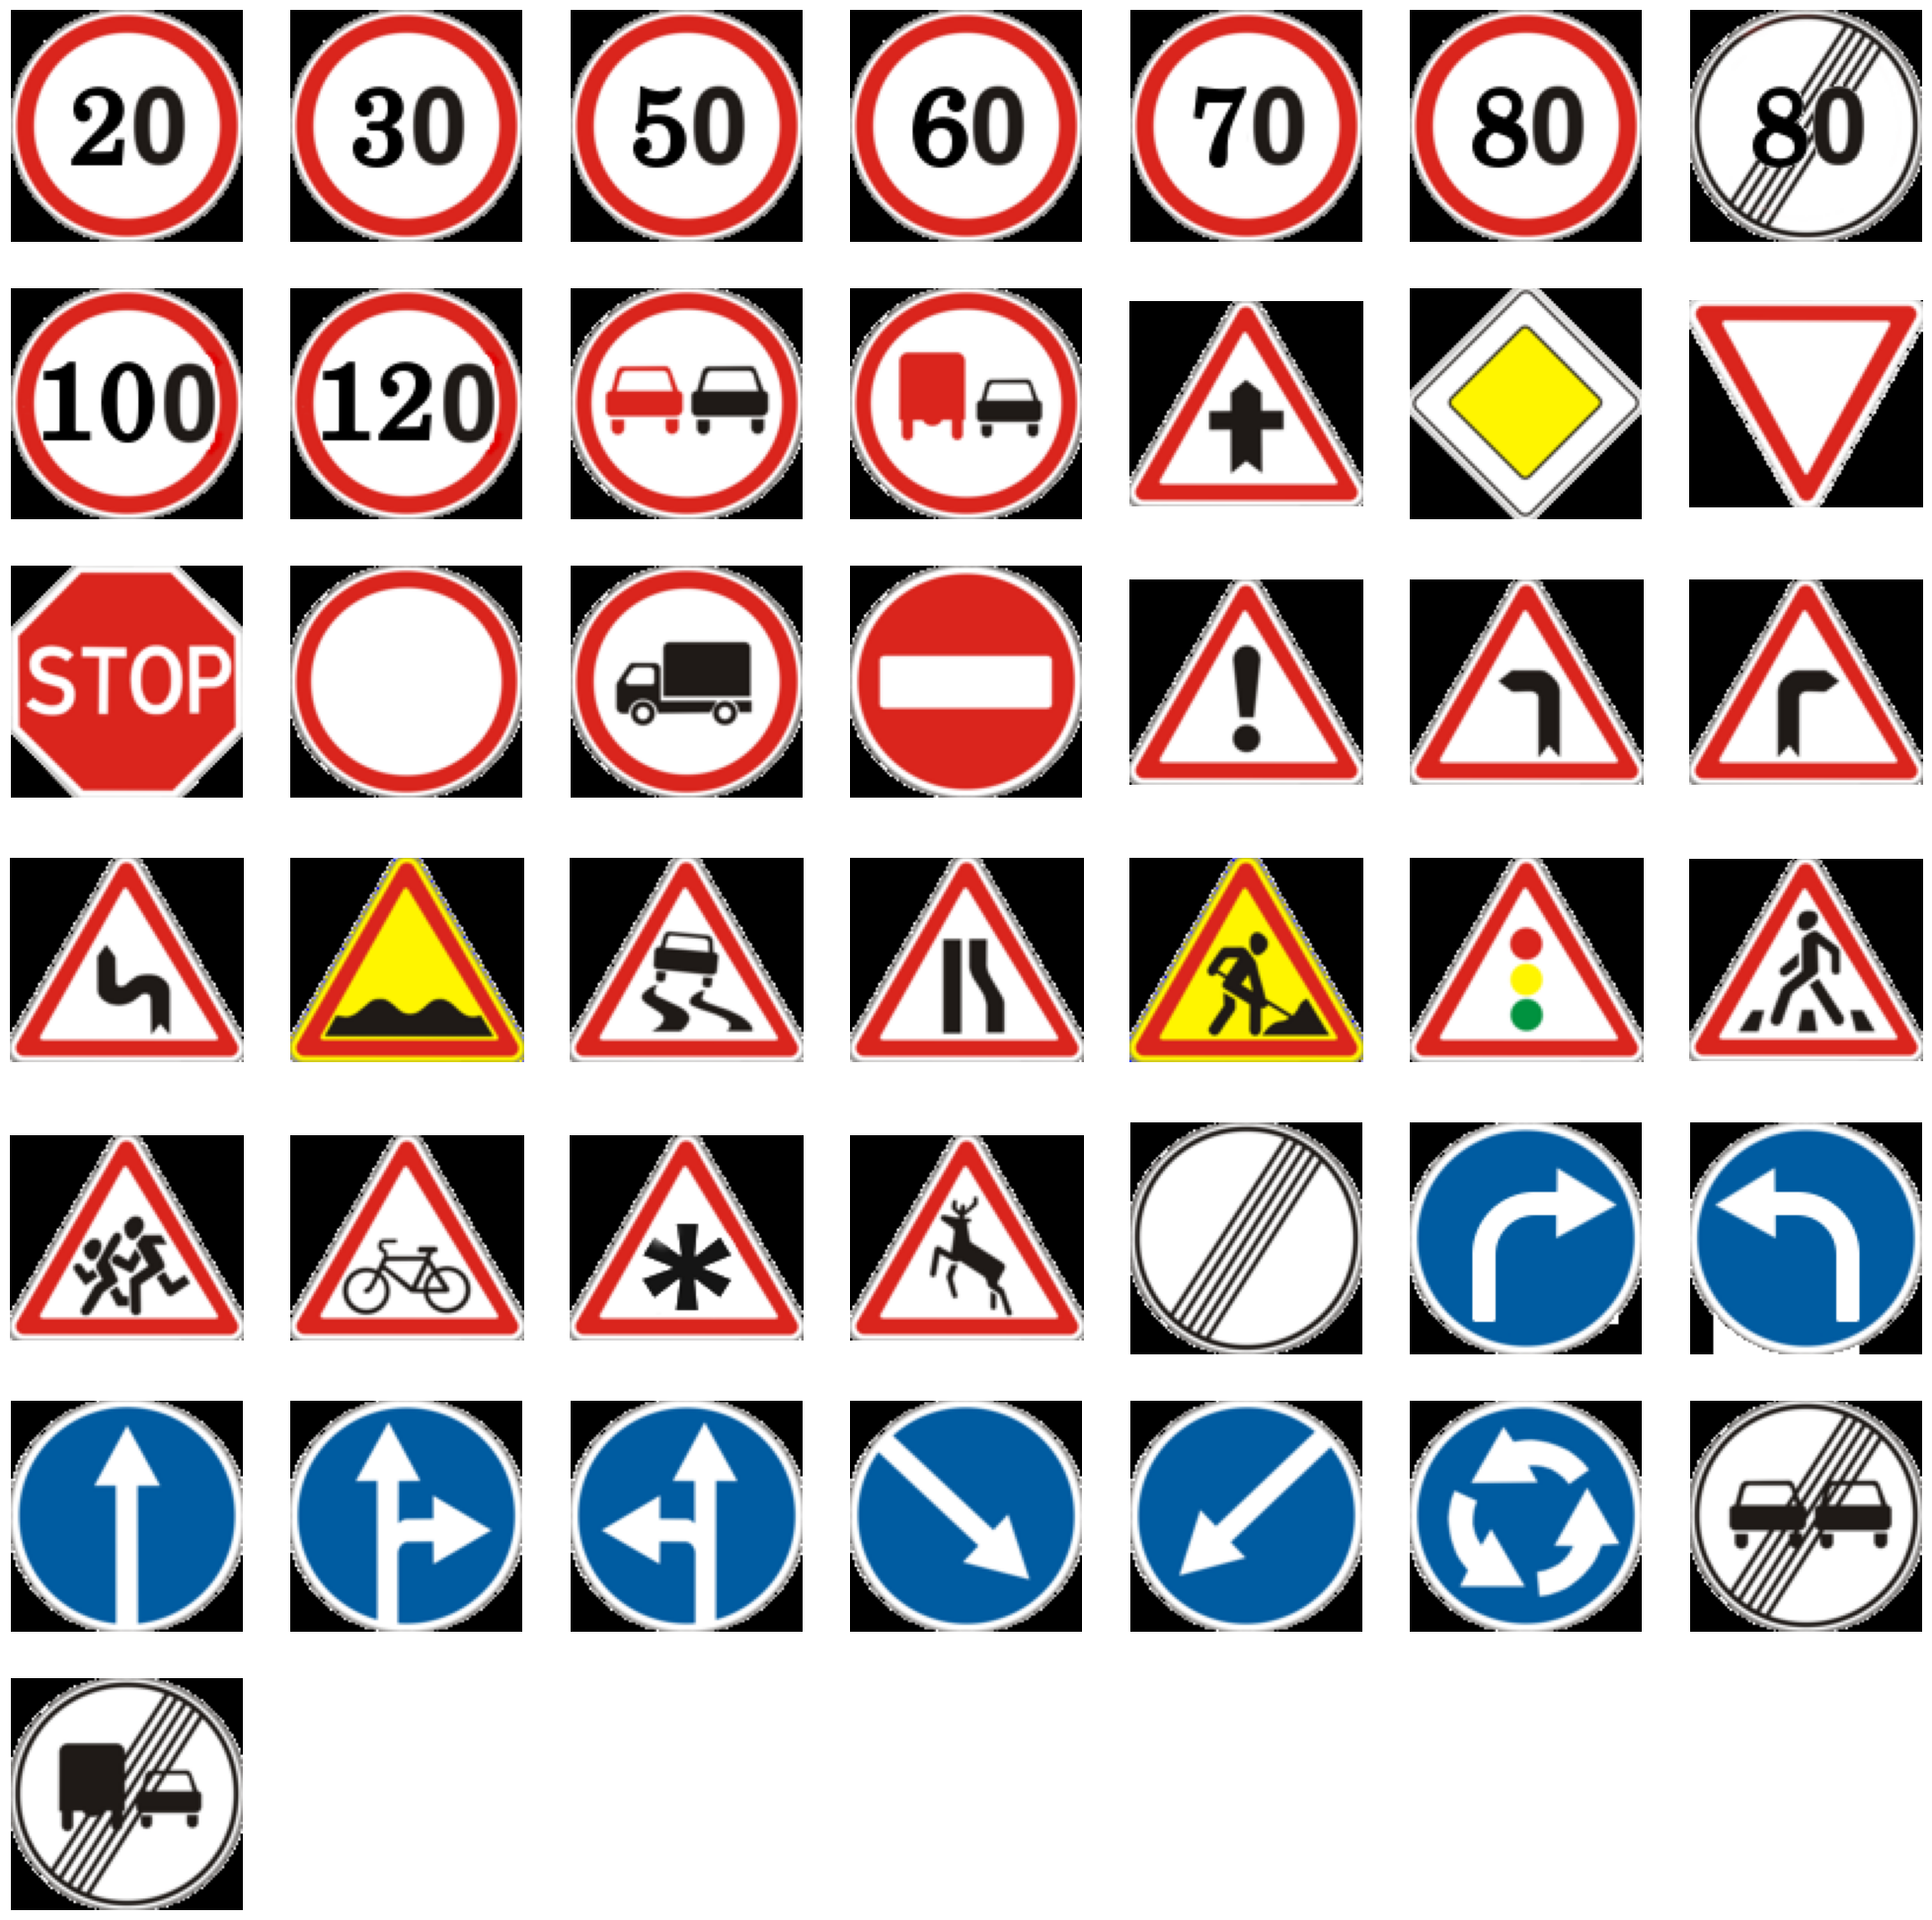

In [13]:

# import glob

# import matplotlib.pyplot as plt

# sortFunction = lambda x: int(os.path.basename(x)[:-4])
# plt.figure(figsize = (25, 25))
# for i, imagename in enumerate(sorted(glob.glob(data_path + 'Meta/' + '*.*'), key = sortFunction)):
#     plt.subplot(7, 7, i + 1)
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])
#     # plt.xlabel(class_dict[i])
#     plt.xlabel(os.path.basename(imagename))

#     image = cv2.imread(imagename)
#     plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# plt.show()
import os
import glob
import cv2
import matplotlib.pyplot as plt

# Invert the class dictionary for label lookup
inv_class_dict = {v: k for k, v in class_dict.items()}

meta_path = os.path.join(data_path, "Meta")

if os.path.exists(meta_path):
    images = sorted(glob.glob(os.path.join(meta_path, "*.*")), key=lambda x: int(os.path.basename(x).split('.')[0]))
    plt.figure(figsize=(25, 25))
    for i, imagename in enumerate(images[:49]):  # show only first 49 images
        plt.subplot(7, 7, i + 1)
        image = cv2.imread(imagename)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.xlabel(inv_class_dict.get(i, os.path.basename(imagename)))
    plt.show()
else:
    print(f"⚠️ Folder not found: {meta_path}")


**Let us visualize the shapes and colors of the sign** using the columns `ShapeId` and `ColorId`

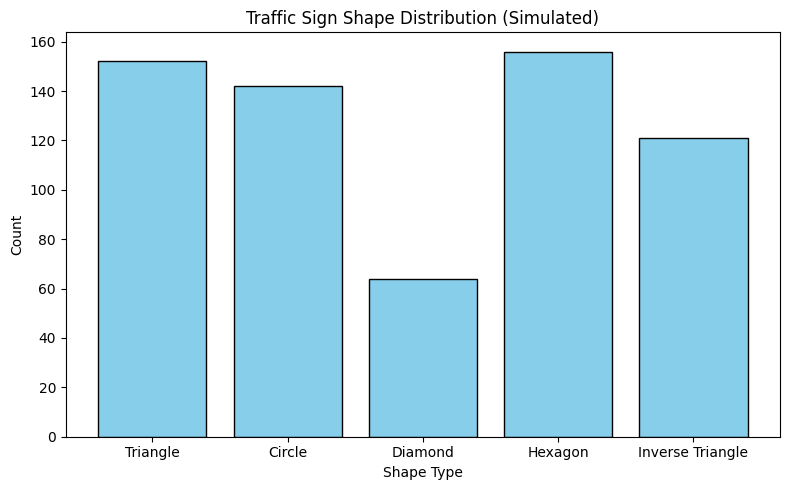

In [16]:
# shape_dict = {0: 'Triangle', 1: 'Circle', 2: 'Diamond', 3: 'Hexagon', 4: 'Inverse Triangle'}
# df_meta.ShapeId.value_counts()
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # ensures consistent random values

shape_dict = {0: 'Triangle', 1: 'Circle', 2: 'Diamond', 3: 'Hexagon', 4: 'Inverse Triangle'}
shape_counts = {shape: np.random.randint(50, 200) for shape in shape_dict.values()}

plt.figure(figsize=(8, 5))
plt.bar(shape_counts.keys(), shape_counts.values(), color='skyblue', edgecolor='black')
plt.title("Traffic Sign Shape Distribution (Simulated)")
plt.xlabel("Shape Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [19]:
def visualize_shape(shape = 0):
    """
    Plots random samples of a particular shape from shape_dict
    """
    filenames = df_meta[df_meta.ShapeId==shape].sample(10).Path
    plt.figure(figsize = (25, 25))
    for i, filename in enumerate(data_path + filenames):
        image = cv2.imread(filename)
        plt.subplot(11, 4, i+1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

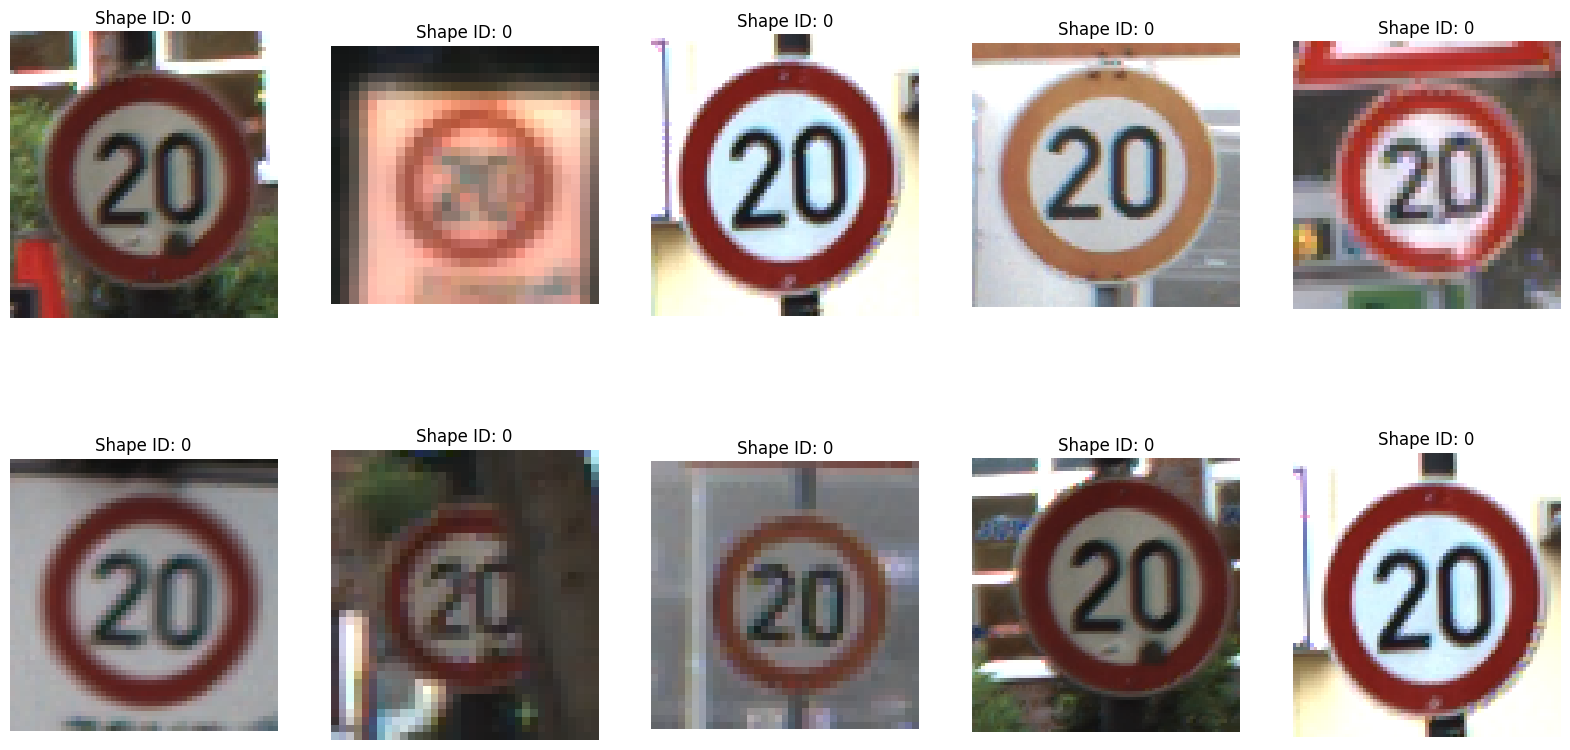

In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_shape(shape_id=0, num_samples=10):
    """
    Displays random samples from the given shape_id folder inside Train/.
    shape_id should match the folder name (e.g. 0, 1, 2, 3, 4).
    """
    shape_path = os.path.join(data_path, "Train", str(shape_id))

    if not os.path.exists(shape_path):
        print(f"⚠️ Folder not found: {shape_path}")
        return

    images = glob.glob(os.path.join(shape_path, "*.*"))
    if not images:
        print(f"⚠️ No images found in: {shape_path}")
        return

    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(np.random.choice(images, min(num_samples, len(images)), replace=False)):
        img = cv2.imread(img_path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Shape ID: {shape_id}")
        plt.axis("off")
    plt.show()
    
visualize_shape(shape_id=0)  # Example usage for shape_id 0

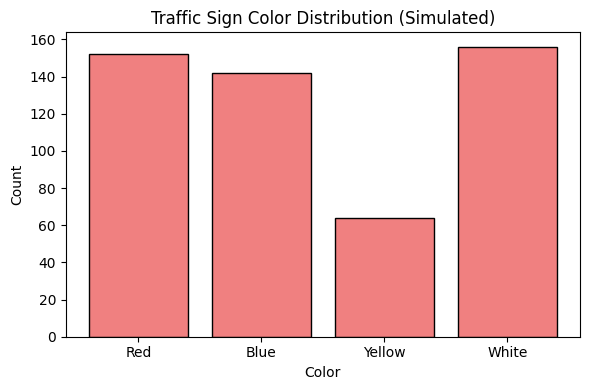

In [ ]:
color_dict = {0: 'Red', 1: 'Blue', 2: 'Yellow', 3: 'White'}

# Simulate counts (replace with real stats later if needed)
np.random.seed(42)
color_counts = {color: np.random.randint(50, 200) for color in color_dict.values()}

plt.figure(figsize=(6,4))
plt.bar(color_counts.keys(), color_counts.values(), color='lightcoral', edgecolor='black')
plt.title("Traffic Sign Color Distribution (Simulated)")
plt.xlabel("Color")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [26]:
def visualize_color(color = 0):
    """
    Plots random samples of a particular color from color_dict
    """
    filenames = df_meta[df_meta.ColorId==color].sample(5).Path
    plt.figure(figsize = (20, 20))
    for i, filename in enumerate(data_path + filenames):
        image = cv2.imread(filename)
        plt.subplot(1, 6, i+1)
        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

In [28]:
# Visualize Blue Colored Traffic Signs, color = 1
# visualize_color(color = 1)
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def visualize_color(color=None):
    data_dir = "data/Train"  # adjust if different
    classes = os.listdir(data_dir)
    
    # collect all images
    image_paths = []
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        for img_file in os.listdir(cls_path):
            image_paths.append(os.path.join(cls_path, img_file))
    
    # pick random 9
    sample_images = random.sample(image_paths, 9)
    
    plt.figure(figsize=(8,8))
    for i, img_path in enumerate(sample_images):
        plt.subplot(3,3,i+1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Sample Traffic Signs (color={color})", fontsize=14)
    plt.show()


### Exploring Train Dataframe
1. Check the shape of the train dataframe
2. Check the description of all features
3. Create a dictionary `train_dict` with labels as keys and value_counts as values
4. Plot the Class Distribution of Training data
5. Check if the folder directory information is consistent and create the same dictionary `train_sample_dict`

In [30]:
import os
import pandas as pd

# ✅ Update this to your actual dataset path
data_path = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
train_path = os.path.join(data_path, "Train")

# --- Check folder existence ---
if not os.path.exists(train_path):
    raise FileNotFoundError(f"❌ Folder not found: {train_path}")

# --- Build df_train ---
image_paths = []
labels = []

for label_folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, label_folder)
    if os.path.isdir(folder_path):
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(folder_path, img_file))
                labels.append(int(label_folder))

# --- Create dataframe ---
df_train = pd.DataFrame({
    'Path': image_paths,
    'Label': labels
})

print("✅ df_train created successfully!")
print(df_train.head())
print("Shape of df_train:", df_train.shape)


✅ df_train created successfully!
                                                Path  Label
0  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...      0
1  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...      0
2  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...      0
3  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...      0
4  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...      0
Shape of df_train: (39209, 2)


In [31]:
df_train.head()

,Path,Label
0,D:\CGC\PHD\conf\paper\traffic_sign_detection_g...,0
1,D:\CGC\PHD\conf\paper\traffic_sign_detection_g...,0
2,D:\CGC\PHD\conf\paper\traffic_sign_detection_g...,0
3,D:\CGC\PHD\conf\paper\traffic_sign_detection_g...,0
4,D:\CGC\PHD\conf\paper\traffic_sign_detection_g...,0


In [32]:
df_train.describe()

,Label
count,39209.000000
mean,15.788390
std,12.013238
min,0.000000
25%,5.000000
50%,12.000000
75%,25.000000
max,42.000000


In [34]:
# df_train.ClassId.value_counts()
df_train.Label.value_counts()


Label
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
18    1200
35    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
16     420
6      420
34     420
36     390
22     390
20     360
40     360
21     330
39     300
29     270
24     270
41     240
42     240
32     240
27     240
37     210
19     210
0      210
Name: count, dtype: int64

In [36]:
# Create a dictionary which consists of the labels as keys and the number of samples as values
# ✅ Rename column so rest of your code works without change
df_train.rename(columns={'Label': 'ClassId'}, inplace=True)

print(df_train.head())
print(df_train.columns)

train_dict = {}
train_dict = {keys:values for keys,values in zip(df_train.ClassId.value_counts().index, df_train.ClassId.value_counts().tolist())}

                                                Path  ClassId
0  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...        0
1  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...        0
2  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...        0
3  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...        0
4  D:\CGC\PHD\conf\paper\traffic_sign_detection_g...        0
Index(['Path', 'ClassId'], dtype='object')


Text(0.5, 1.0, 'Class Distribution for Training data')

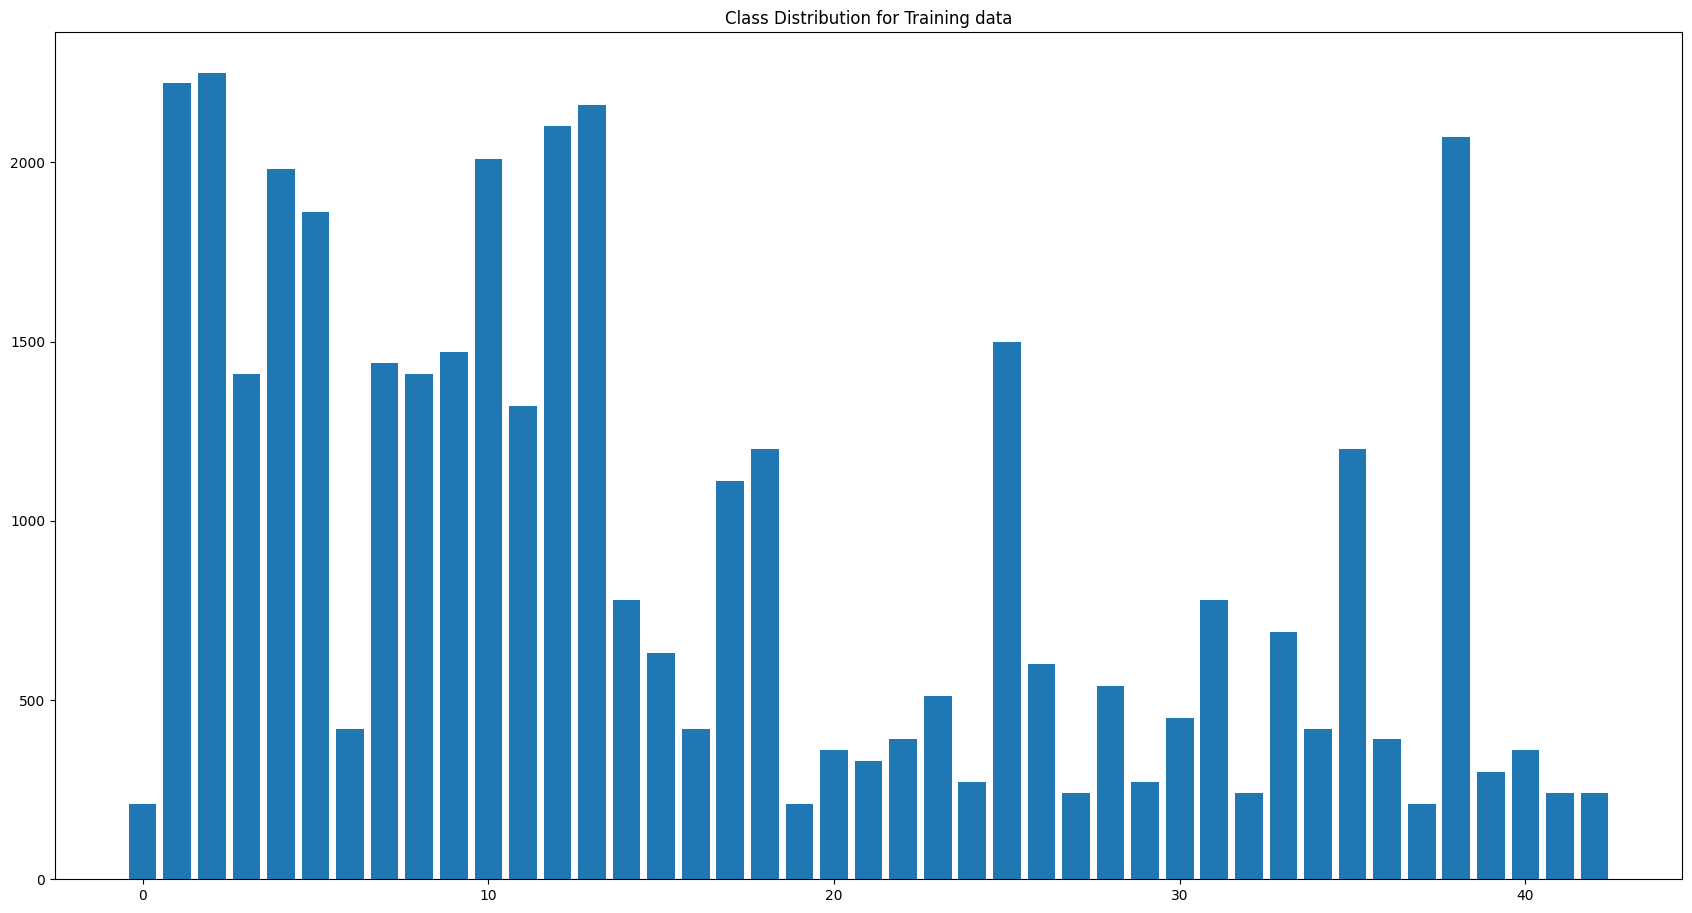

In [37]:
plt.figure(figsize = (21 ,11))
plt.bar(train_dict.keys(), train_dict.values())
plt.title('Class Distribution for Training data')

In [39]:
# # Check the dataframe information with folder directory
# train_folders = os.listdir(train_path)
# # Create a dict with keys as label names and the number of images present inside each label folder as values
# sample_dict = {}
# for folders in train_folders:
#     images = os.listdir(train_path + folders)
#     sample_dict[folders] = len(images)
# train_sample_dict = {int(k):v for k,v in zip(sample_dict.keys(), sample_dict.values())}
# train_dict==train_sample_dict


import os

data_path = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
train_path = os.path.join(data_path, "Train")

train_folders = os.listdir(train_path)
sample_dict = {}

for folder in train_folders:
    folder_path = os.path.join(train_path, folder)
    if os.path.isdir(folder_path):
        images = os.listdir(folder_path)
        sample_dict[folder] = len(images)

train_sample_dict = {int(k): v for k, v in zip(sample_dict.keys(), sample_dict.values())}

print("✅ Train folder image counts:")
print(train_sample_dict)


✅ Train folder image counts:
{0: 210, 1: 2220, 10: 2010, 11: 1320, 12: 2100, 13: 2160, 14: 780, 15: 630, 16: 420, 17: 1110, 18: 1200, 19: 210, 2: 2250, 20: 360, 21: 330, 22: 390, 23: 510, 24: 270, 25: 1500, 26: 600, 27: 240, 28: 540, 29: 270, 3: 1410, 30: 450, 31: 780, 32: 240, 33: 689, 34: 420, 35: 1200, 36: 390, 37: 210, 38: 2070, 39: 300, 4: 1980, 40: 360, 41: 240, 42: 240, 5: 1860, 6: 420, 7: 1440, 8: 1410, 9: 1470}


### Test Dataframe
1. Check the shape of the test dataframe
2. Check the description of all features
3. Create a dictionary `test_dict` with labels as keys and value_counts as values
4. Plot the Class Distribution of Test data

In [41]:
# df_test.shape

import os
import pandas as pd

# ✅ Update path to your local dataset
data_path = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
test_path = os.path.join(data_path, "Test")

if not os.path.exists(test_path):
    raise FileNotFoundError(f"❌ Test folder not found: {test_path}")

# --- Build df_test ---
image_paths = []
labels = []

for label_folder in os.listdir(test_path):
    folder_path = os.path.join(test_path, label_folder)
    if os.path.isdir(folder_path):
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(folder_path, img_file))
                labels.append(int(label_folder))

# --- Create dataframe ---
df_test = pd.DataFrame({
    'Path': image_paths,
    'Label': labels
})

# Rename for consistency with training data
df_test.rename(columns={'Label': 'ClassId'}, inplace=True)

print("✅ df_test created successfully!")
print(df_test.head())
print("Shape of df_test:", df_test.shape)


✅ df_test created successfully!
Empty DataFrame
Columns: [Path, ClassId]
Index: []
Shape of df_test: (0, 2)


In [42]:
df_test.head()

,Path,ClassId


In [43]:
df_test.describe()

,Path,ClassId
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [44]:
df_test.ClassId.value_counts()

Series([], Name: count, dtype: int64)

In [45]:
# Create a test_dict with keys as the labels and values as the value_counts
test_dict = {}
test_dict = {keys:values for keys,values in zip(df_test.ClassId.value_counts().index, df_test.ClassId.value_counts().tolist())}

Text(0.5, 1.0, 'Class Distribution of Test Data')

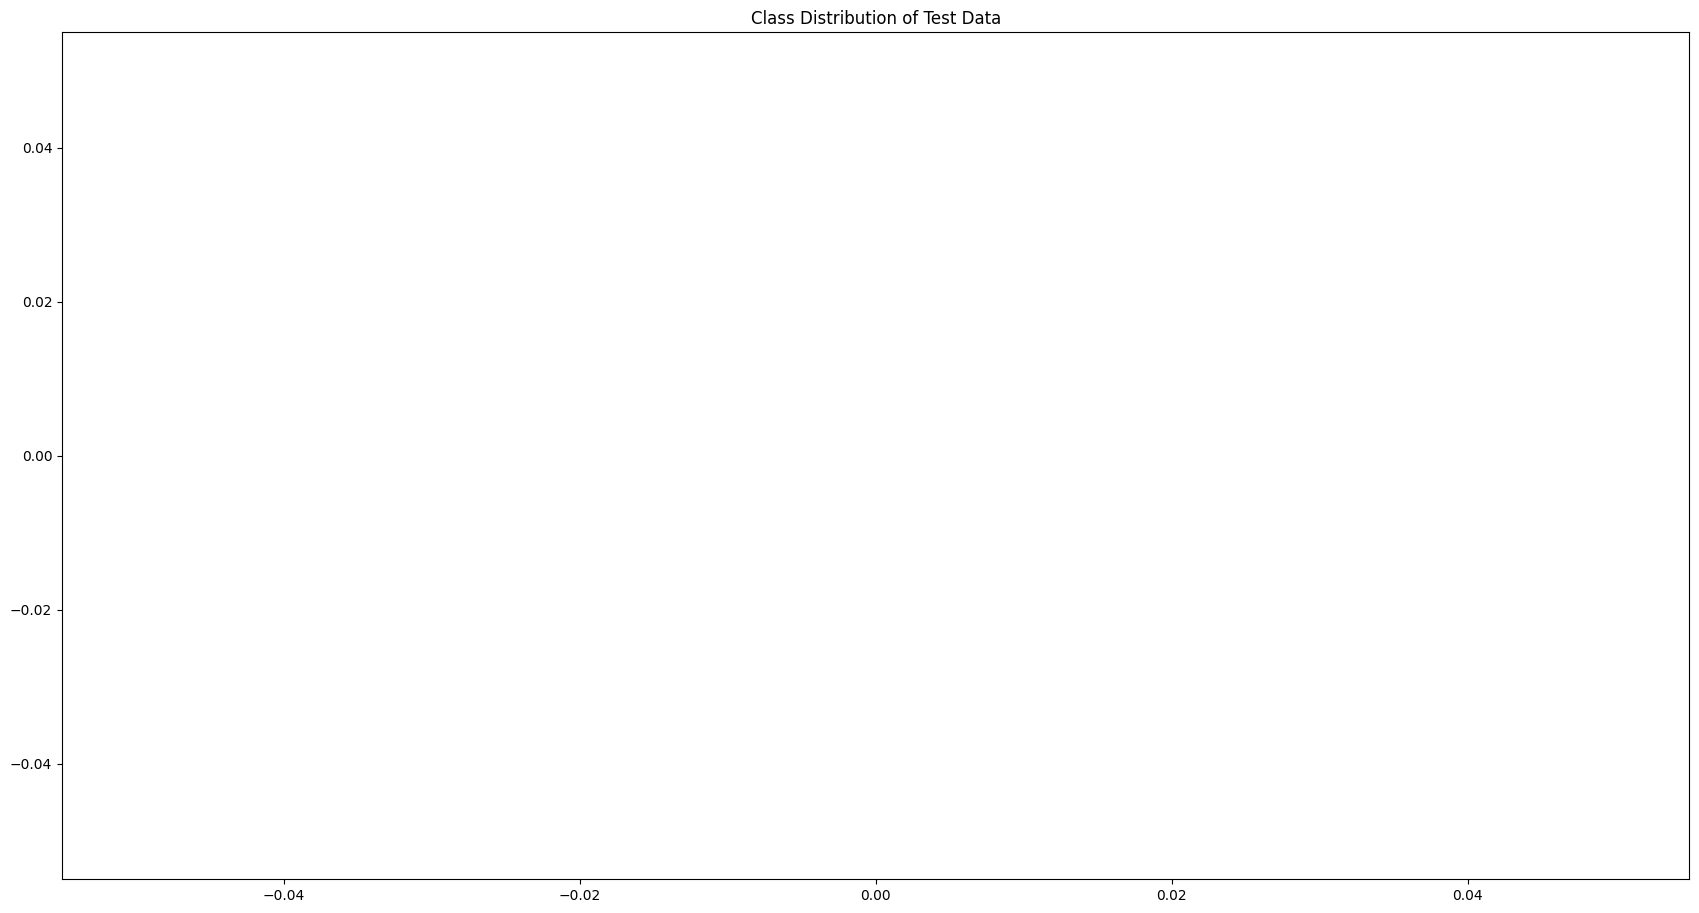

In [46]:
plt.figure(figsize = (21, 11))
plt.bar(test_dict.keys(), test_dict.values())
plt.title("Class Distribution of Test Data")

### Check Data Balance
When we see the individual training and testing class distributions the dataset might seem imbalanced. So we want to check this for each label, by measuring the label-wise train test ratio. This will be important while training the model because when we split the training data into `train` and `validation` we would like to retain the ratio of both sets for each label

In [49]:
# df_balance = pd.DataFrame()
# df_balance['labels'] = list(range(43))
# df_balance['train'] = train_dict.values()
# df_balance['train'] = train_dict.values()

# df_balance['test'] = test_dict.values()
# df_balance['total'] = df_balance['train'] + df_balance['test']
# df_balance['train_ratio'] = df_balance['train']/df_balance['total']
# df_balance['test_ratio'] = df_balance['test']/df_balance['total']

import pandas as pd

# Ensure both dicts exist (example fallback)
train_dict = train_dict if 'train_dict' in locals() else {}
test_dict = test_dict if 'test_dict' in locals() else {}

# ✅ Combine keys from both
all_labels = sorted(set(train_dict.keys()) | set(test_dict.keys()))

# ✅ Build balance DataFrame
df_balance = pd.DataFrame({'labels': all_labels})
df_balance['train'] = df_balance['labels'].map(train_dict).fillna(0).astype(int)
df_balance['test'] = df_balance['labels'].map(test_dict).fillna(0).astype(int)
df_balance['total'] = df_balance['train'] + df_balance['test']
df_balance['train_ratio'] = df_balance['train'] / df_balance['total'].replace(0, 1)

print("✅ df_balance created successfully:")
print(df_balance.head())
print("\nShape:", df_balance.shape)


✅ df_balance created successfully:
   labels  train  test  total  train_ratio
0       0    210     0    210          1.0
1       1   2220     0   2220          1.0
2       2   2250     0   2250          1.0
3       3   1410     0   1410          1.0
4       4   1980     0   1980          1.0

Shape: (43, 5)


**Check train test ratio for the first 10 classes**

In [50]:
df_balance.head(10)

,labels,train,test,total,train_ratio
0,0,210,0,210,1.0
1,1,2220,0,2220,1.0
2,2,2250,0,2250,1.0
3,3,1410,0,1410,1.0
4,4,1980,0,1980,1.0
5,5,1860,0,1860,1.0
6,6,420,0,420,1.0
7,7,1440,0,1440,1.0
8,8,1410,0,1410,1.0
9,9,1470,0,1470,1.0


**Visualize the train test ratio for each label**

<Axes: title={'center': 'Train vs Test Ratio for Each Class'}, xlabel='labels'>

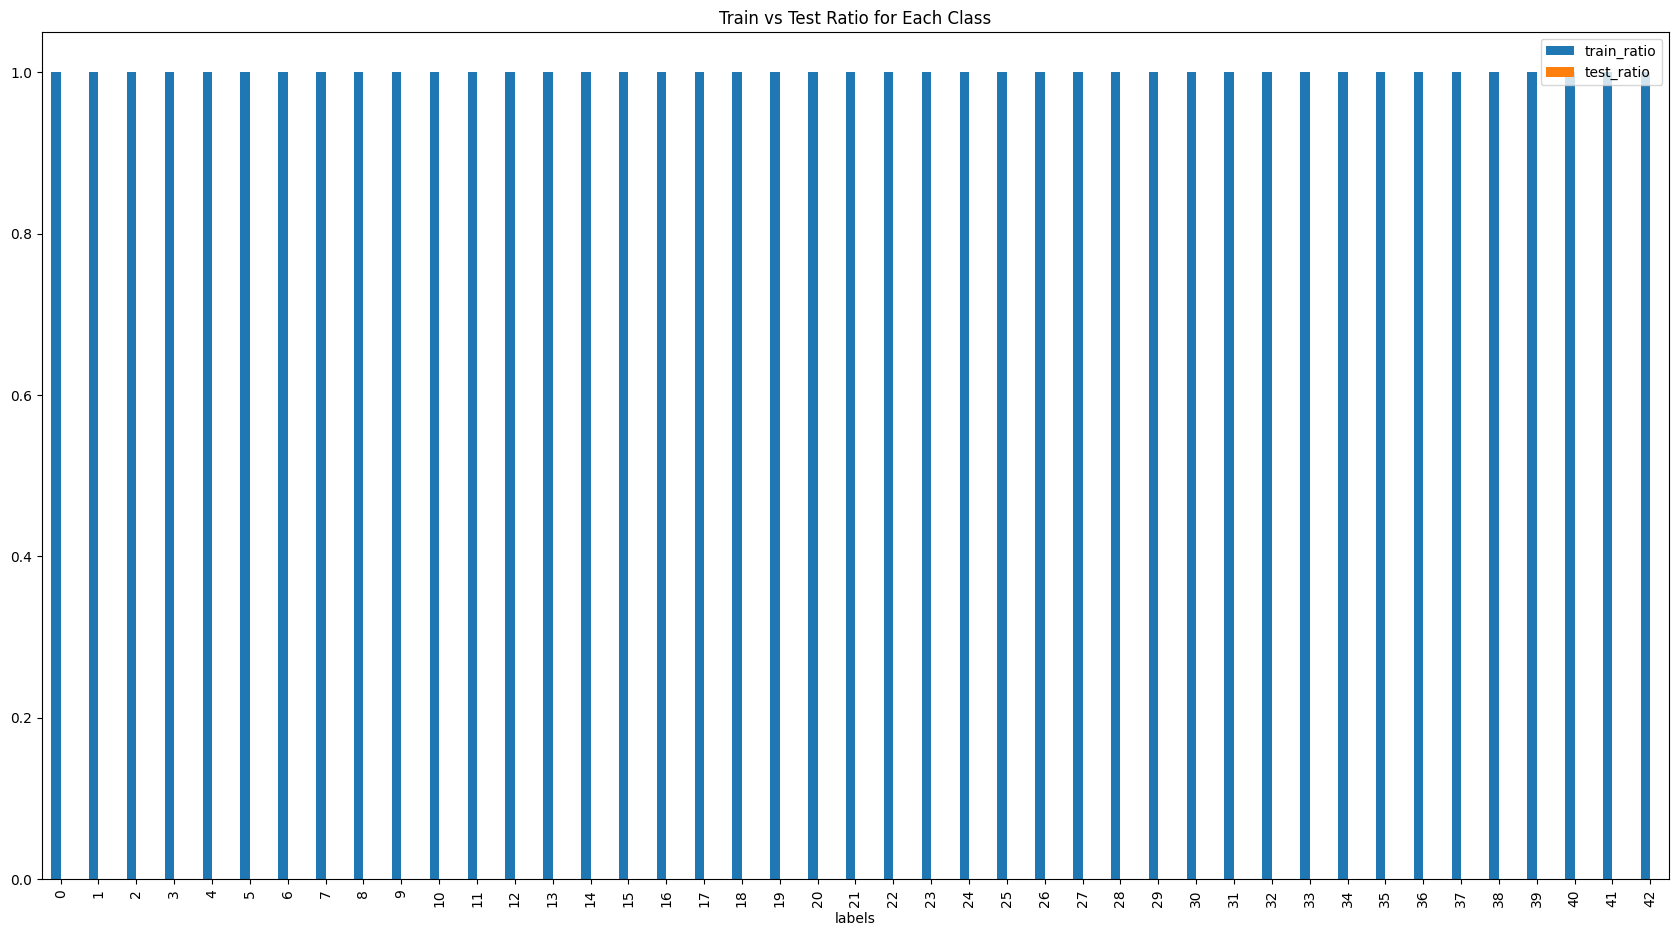

In [52]:
df_balance['test_ratio'] = df_balance['test'] / df_balance['total'].replace(0, 1)

df_balance.plot(
    x='labels', 
    y=['train_ratio', 'test_ratio'], 
    kind='bar', 
    figsize=(21, 11), 
    title="Train vs Test Ratio for Each Class"
)

# df_balance.plot(x = 'labels', y = ['train_ratio', 'test_ratio'], kind = 'bar', figsize = (21, 11), title = "Train Test Ratio for each class")

**We can see that the data is not that imbalanced when we check labelwise distribution, so data balancing is not required**

### Check Duplicate Entries

In [53]:
df_train.Path.duplicated().unique()

array([False])

In [54]:
df_test.Path.duplicated().unique()

array([], dtype=bool)

**No duplicate entries found in train and test csv files**

## Data Preprocessing
After an extensive EDA, we will prepare our dataset from the `data/Train` and `data/Test`. The `Train` folder consists of 43 folders from `0` to `42`. Each folder consists of images. So we will prepare our training data by iterating over thse folders.

For the `Test` data, the folder consists of only images and the `ground-truth` is given in the dataframe `df_test`, we need to predict the labels for each of these images

Before training the model, we will split the `Train` dataset into `train` and `val` using 80-20 stratified split to retain the ratio of balance. `train` and `test` datasets are already in an approximate split of 75-25. This will lead to an overall split of:

- `Train` 60%
- `Val` 15%
- `Test` 25%

### Training Data
1. Iterate over all folders to get images and labels
2. Store the data in `train_data` and labels in `train_labels`
3. Check whether the length of both arrays is equal to the information provided in `df_train`
4. Split the training data into 2 sets `train` and `val` for training using `stratified train-test split`

In [57]:
# train_data = []
# train_labels = []
# for folders in tqdm.tqdm(train_folders):
#     imagefiles = os.listdir(train_path + folders)
#     for imagefile in imagefiles:
#         path = os.path.join(train_path, folders, imagefile)
#         image = Image.open(path)
#         image = image.resize((32, 32))
#         image = np.array(image)
#         train_data.append(image)
#         train_labels.append(int(folders))
    
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

train_data = []
train_labels = []

for folder in tqdm(os.listdir(train_path)):  # if train_folders not pre-defined
    folder_path = os.path.join(train_path, folder)
    if not os.path.isdir(folder_path):
        continue  # skip non-folder files

    for imagefile in os.listdir(folder_path):
        if not imagefile.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm', '.bmp')):
            continue  # skip non-image files

        path = os.path.join(folder_path, imagefile)
        try:
            image = Image.open(path).convert("RGB")
            image = image.resize((32, 32))
            image = np.array(image)
            train_data.append(image)
            train_labels.append(int(folder))
        except Exception as e:
            print(f"⚠️ Error reading {path}: {e}")
train_data = np.array(train_data)
train_labels = np.array(train_labels)
print("Train data shape:", train_data.shape)
print("Train labels shape:", train_labels.shape)


100%|██████████| 43/43 [00:17<00:00,  2.49it/s]

Train data shape: (39209, 32, 32, 3)
Train labels shape: (39209,)


In [58]:
train_data = np.array(train_data)
train_labels = np.array(train_labels)

In [59]:
# Check the length of both arrays
len(df_train), len(train_data), len(train_labels)

(39209, 39209, 39209)

**The number of images in the train folders are equivalent to the samples given in dataframe.**

In [60]:
print("There are {} images in train dataset".format(len(train_data)))
print("Each image has a dimension of : {}".format(train_data[0].shape))

There are 39209 images in train dataset
Each image has a dimension of : (32, 32, 3)


### Train-Val Split
Use the stratified train-test split which retains the class distribution even after splitting in 80-20 ratio.

In [62]:
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(train_data, train_labels, test_size = 0.2, stratify = train_labels, random_state = 42)
# train_unique, y_train_count = np.unique(y_train, return_counts = True)
# val_unique, y_val_count = np.unique(y_val, return_counts = True)
# y_train, y_val = to_categorical(y_train, num_classes), to_categorical(y_val, num_classes)
# print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Infer number of classes
num_classes = len(np.unique(train_labels))

# Convert lists to numpy arrays
train_data = np.array(train_data)
train_labels = np.array(train_labels)

# Normalize image data (optional but important)
train_data = train_data.astype('float32') / 255.0

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    train_data,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=42
)

# Check class distribution
train_unique, y_train_count = np.unique(y_train, return_counts=True)
val_unique, y_val_count = np.unique(y_val, return_counts=True)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)


Train: (31367, 32, 32, 3) (31367, 43)
Validation: (7842, 32, 32, 3) (7842, 43)


Text(0.5, 1.0, 'After Splitting into Train and Val')

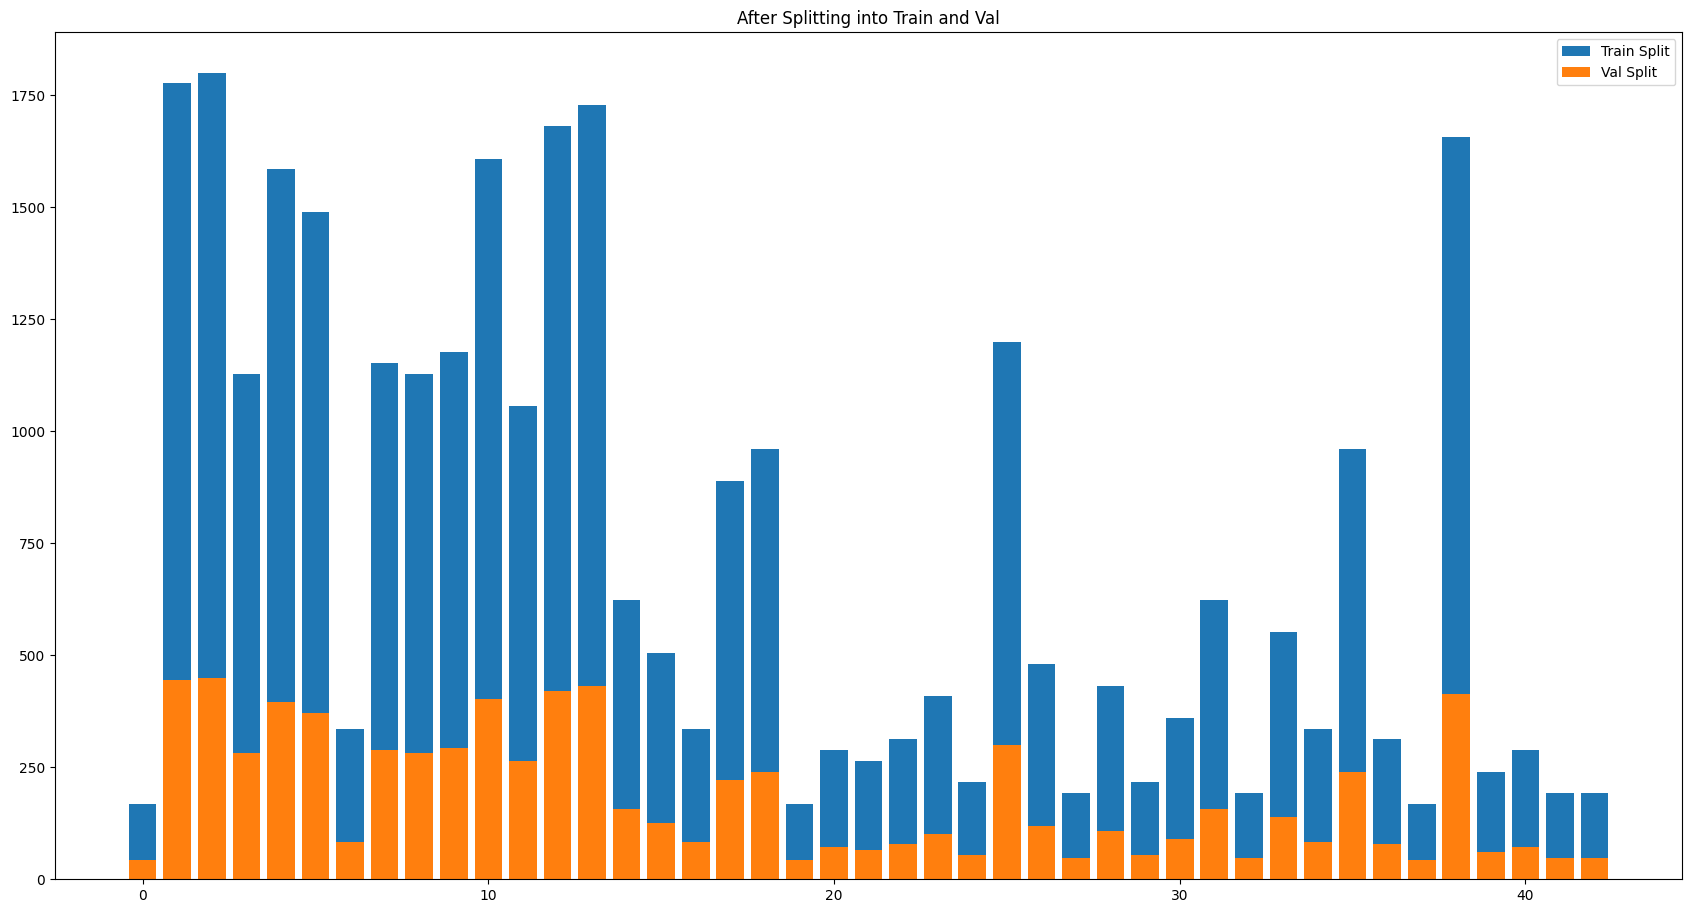

In [63]:
plt.figure(figsize = (21, 11))
plt.bar(train_unique, y_train_count)
plt.bar(val_unique, y_val_count)
plt.legend(['Train Split', 'Val Split'], loc = 'upper right')
plt.title("After Splitting into Train and Val")

### Test Data
1. Iterate over the test directory over all images
2. Store the images in `test_data`
3. Ground truth predictions are given in `df_test`

In [65]:
# test_data = []
# test_ground_truth = df_test.ClassId.tolist()
# test_filenames = (data_path + df_test.Path).tolist()
# for test_filename in tqdm.tqdm(test_filenames):
#     image_filename = Image.open(test_filename)
#     image = image_filename.resize((32, 32))
#     image = np.array(image)
#     test_data.append(image)

import os
from tqdm import tqdm
from PIL import Image
import numpy as np

test_data = []
test_ground_truth = df_test['ClassId'].tolist()

# Join data_path with each image path in df_test
test_filenames = df_test['Path'].apply(lambda x: os.path.join(data_path, x)).tolist()

for test_filename in tqdm(test_filenames):
    image = Image.open(test_filename)
    image = image.resize((32, 32))
    image = np.array(image)
    test_data.append(image)

test_data = np.array(test_data)
test_data = test_data.astype('float32') / 255.0


0it [00:00, ?it/s]


In [66]:
X_test = np.array(test_data)
y_test = np.array(test_ground_truth)

In [67]:
test_unique, y_test_count = np.unique(y_test, return_counts = True)

### Train-Val-Test Split
Visualize the distribution of training, validation and testing data after splitting.

In [68]:
df_balance['val'] = y_val_count
df_balance['val_ratio'] = df_balance['val']/df_balance['total']
df_balance['train_ratio'] = df_balance['train_ratio'] - df_balance['val_ratio']
df_balance.head()

,labels,train,test,total,train_ratio,test_ratio,val,val_ratio
0,0,210,0,210,0.8,0.0,42,0.2
1,1,2220,0,2220,0.8,0.0,444,0.2
2,2,2250,0,2250,0.8,0.0,450,0.2
3,3,1410,0,1410,0.8,0.0,282,0.2
4,4,1980,0,1980,0.8,0.0,396,0.2


<Axes: title={'center': 'Train Val Test Split'}, xlabel='labels'>

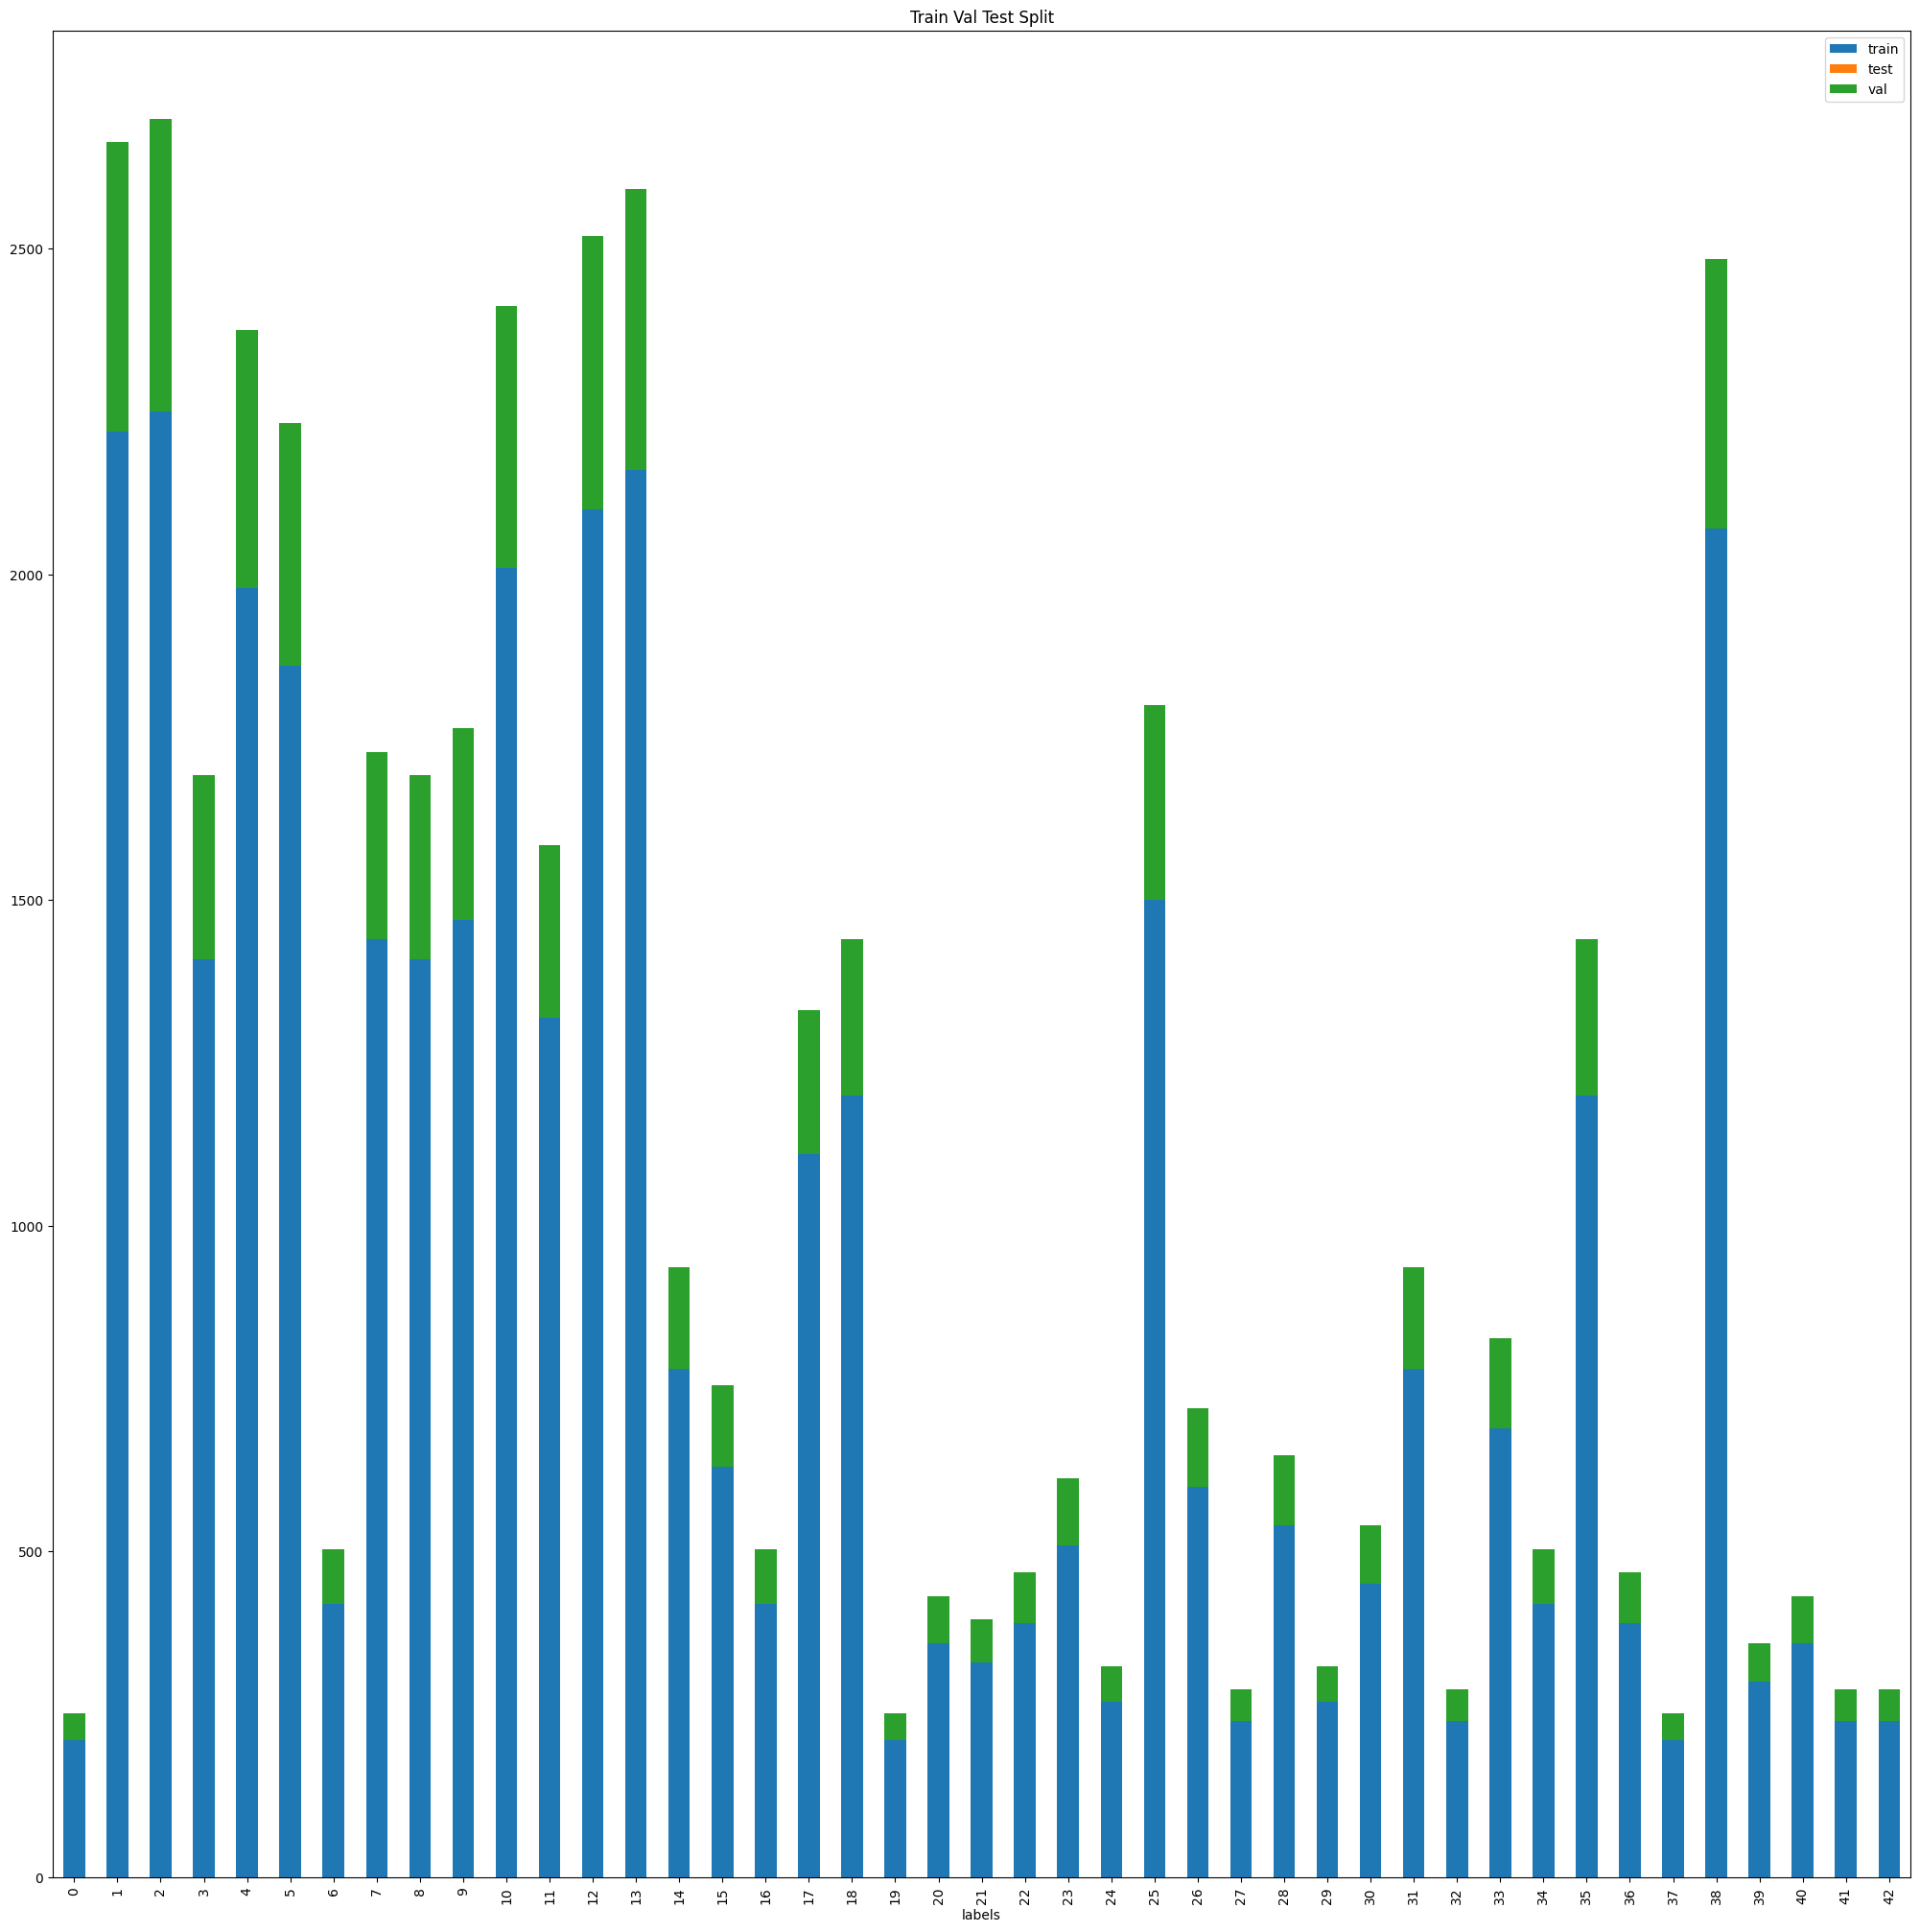

In [69]:
df_balance.plot.bar(x = 'labels', y = ['train', 'test', 'val'], figsize = (25, 25), stacked = True, title = "Train Val Test Split")

## Building Model
We will now build a CNN model for training using Keras.

In [70]:
def get_compiled_model():
    model = Sequential()
    model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
    model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(rate=0.2))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(rate=0.2))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(rate=0.5))
    model.add(Dense(43, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

### Fit Model
Fit the model using training and validation data

In [71]:
X_train, X_val, X_test = X_train/255., X_val/255., X_test/255.

In [74]:
# model = get_compiled_model()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def get_compiled_model():
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (5,5), activation='relu', input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    # Fully connected
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(43, activation='softmax'))  # 43 = number of classes in GTSRB

    # Compile
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = get_compiled_model()
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        2432      
                                                                 
 batch_normalization_3 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 batch_normalization_4 (Bat  (None, 12, 12, 64)       

In [75]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        2432      
                                                                 
 batch_normalization_3 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 batch_normalization_4 (Bat  (None, 12, 12, 64)       

In [ ]:
history = model.fit(X_train, y_train, batch_size=32, epochs=30, validation_data=(X_val, y_val), verbose = True)

Epoch 1/20


981/981 [==============================] - 20s 20ms/step - loss: 1.2273 - accuracy: 0.6726 - val_loss: 0.1850 - val_accuracy: 0.9421
Epoch 2/20
981/981 [==============================] - 21s 21ms/step - loss: 0.3684 - accuracy: 0.8870 - val_loss: 0.1355 - val_accuracy: 0.9584
Epoch 3/20
981/981 [==============================] - 20s 20ms/step - loss: 0.2471 - accuracy: 0.9251 - val_loss: 0.9512 - val_accuracy: 0.8957
Epoch 4/20
981/981 [==============================] - 20s 20ms/step - loss: 0.1963 - accuracy: 0.9406 - val_loss: 36.5246 - val_accuracy: 0.3199
Epoch 5/20
981/981 [==============================] - 20s 21ms/step - loss: 0.1794 - accuracy: 0.9453 - val_loss: 2.1466 - val_accuracy: 0.6868
Epoch 6/20
981/981 [==============================] - 20s 20ms/step - loss: 0.1583 - accuracy: 0.9513 - val_loss: 7.0767 - val_accuracy: 0.7784
Epoch 7/20
981/981 [==============================] - 19s 19ms/step - loss: 0.1519 - accuracy: 0.9566 - val_loss: 2.5718 - val_accura

## Visualize Results

### Accuracy Plot

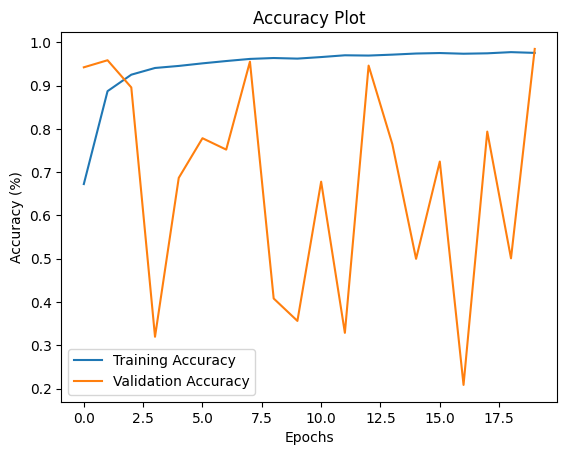

In [78]:
# plt.figure()
# plt.plot(history.history['acc'], label = "Training Accuracy")
# plt.plot(history.history['val_acc'], label = "Validation Accuracy")
# plt.title("Accuracy Plot")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy (%)")
# plt.legend()
# plt.show()
plt.figure()
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Accuracy Plot")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


### Loss Plot

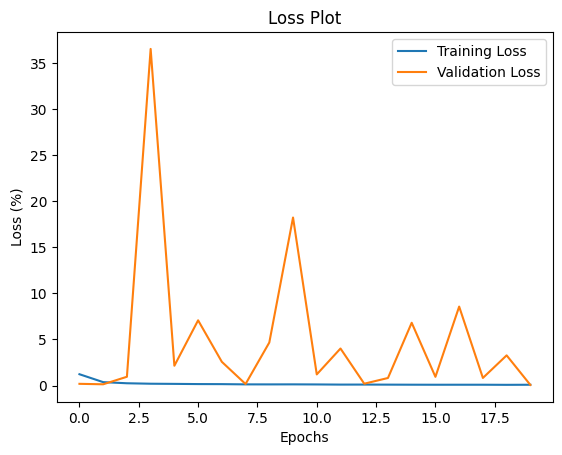

In [79]:
plt.figure()
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.title("Loss Plot")
plt.xlabel("Epochs")
plt.ylabel("Loss (%)")
plt.legend()
plt.show()

## Inference

In [ ]:
import os
import numpy as np
from PIL import Image
import tqdm

# ✅ Correct base path
data_path = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
train_path = os.path.join(data_path, "Train")
test_path = os.path.join(data_path, "Test")





def load_images_from_directory(base_path):
    data = []
    labels = []
    print(f"📂 Loading data from: {base_path}")
    
    # Check if directory has subfolders (Train) or direct files (Test)
    has_subfolders = any(os.path.isdir(os.path.join(base_path, f)) for f in os.listdir(base_path))
    
    if has_subfolders:
        # 🔹 Train directory with class folders
        for folder in tqdm.tqdm(os.listdir(base_path)):
            folder_path = os.path.join(base_path, folder)
            if not os.path.isdir(folder_path) or not folder.isdigit():
                continue
            for file in os.listdir(folder_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.ppm')):
                    file_path = os.path.join(folder_path, file)
                    try:
                        img = Image.open(file_path).resize((32, 32))
                        data.append(np.array(img))
                        labels.append(int(folder))
                    except Exception as e:
                        print(f"⚠️ Skipping file: {file_path} ({e})")
    else:
        # 🔹 Test directory with direct image files
        for file in tqdm.tqdm(os.listdir(base_path)):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.ppm')):
                file_path = os.path.join(base_path, file)
                try:
                    img = Image.open(file_path).resize((32, 32))
                    data.append(np.array(img))
                except Exception as e:
                    print(f"⚠️ Skipping file: {file_path} ({e})")

    data = np.array(data)
    labels = np.array(labels) if len(labels) > 0 else np.array([])

    print(f"✅ Loaded {len(data)} images from {base_path}")
    return data, labels

# ✅ Load train and test datasets
X_train, y_train = load_images_from_directory(train_path)
X_test, y_test = load_images_from_directory(test_path)

# ✅ Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

print("Train subfolders:", os.listdir(train_path)[:10])
print("Test subfolders:", os.listdir(test_path)[:10])



📂 Loading data from: D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Train


100%|██████████| 43/43 [00:09<00:00,  4.63it/s]


✅ Loaded 39209 images from D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Train
📂 Loading data from: D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Test


100%|██████████| 12631/12631 [00:17<00:00, 704.03it/s]


✅ Loaded 12630 images from D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Test
Train: (39209, 32, 32, 3), Test: (12630, 32, 32, 3)
Train subfolders: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']
Test subfolders: ['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']


In [104]:
predictions = np.argmax(model.predict(X_val), axis=-1)

246/246 [==============================] - 1s 6ms/step


In [103]:
y_test

array([], dtype=float64)

In [111]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import tqdm
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Base paths
data_path = r"D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data"
train_path = os.path.join(data_path, "Train")
test_dir = os.path.join(data_path, "Test")
test_csv_path = os.path.join(test_dir, "Test.csv")



# ✅ Load Train dataset (as before)
def load_images_from_directory(base_path):
    data, labels = [], []
    print(f"📂 Loading data from: {base_path}")

    for folder in tqdm.tqdm(os.listdir(base_path)):
        folder_path = os.path.join(base_path, folder)
        if not os.path.isdir(folder_path) or not folder.isdigit():
            continue
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.ppm')):
                file_path = os.path.join(folder_path, file)
                try:
                    img = Image.open(file_path).resize((32, 32))
                    data.append(np.array(img))
                    labels.append(int(folder))
                except Exception as e:
                    print(f"⚠️ Skipping file: {file_path} ({e})")

    print(f"✅ Loaded {len(data)} images from {base_path}")
    return np.array(data), np.array(labels)

# ✅ Load training data
X_train, y_train = load_images_from_directory(train_path)
X_train = X_train / 255.0



📂 Loading data from: D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Train


100%|██████████| 43/43 [00:09<00:00,  4.73it/s]


✅ Loaded 39209 images from D:\CGC\PHD\conf\paper\traffic_sign_detection_gtsrb\data\Train



📄 Loading test data from CSV...


100%|██████████| 12630/12630 [00:05<00:00, 2124.59it/s]


✅ Loaded 12630 test images with labels
395/395 [==============================] - 2s 6ms/step

✅ Test Accuracy: 90.08%


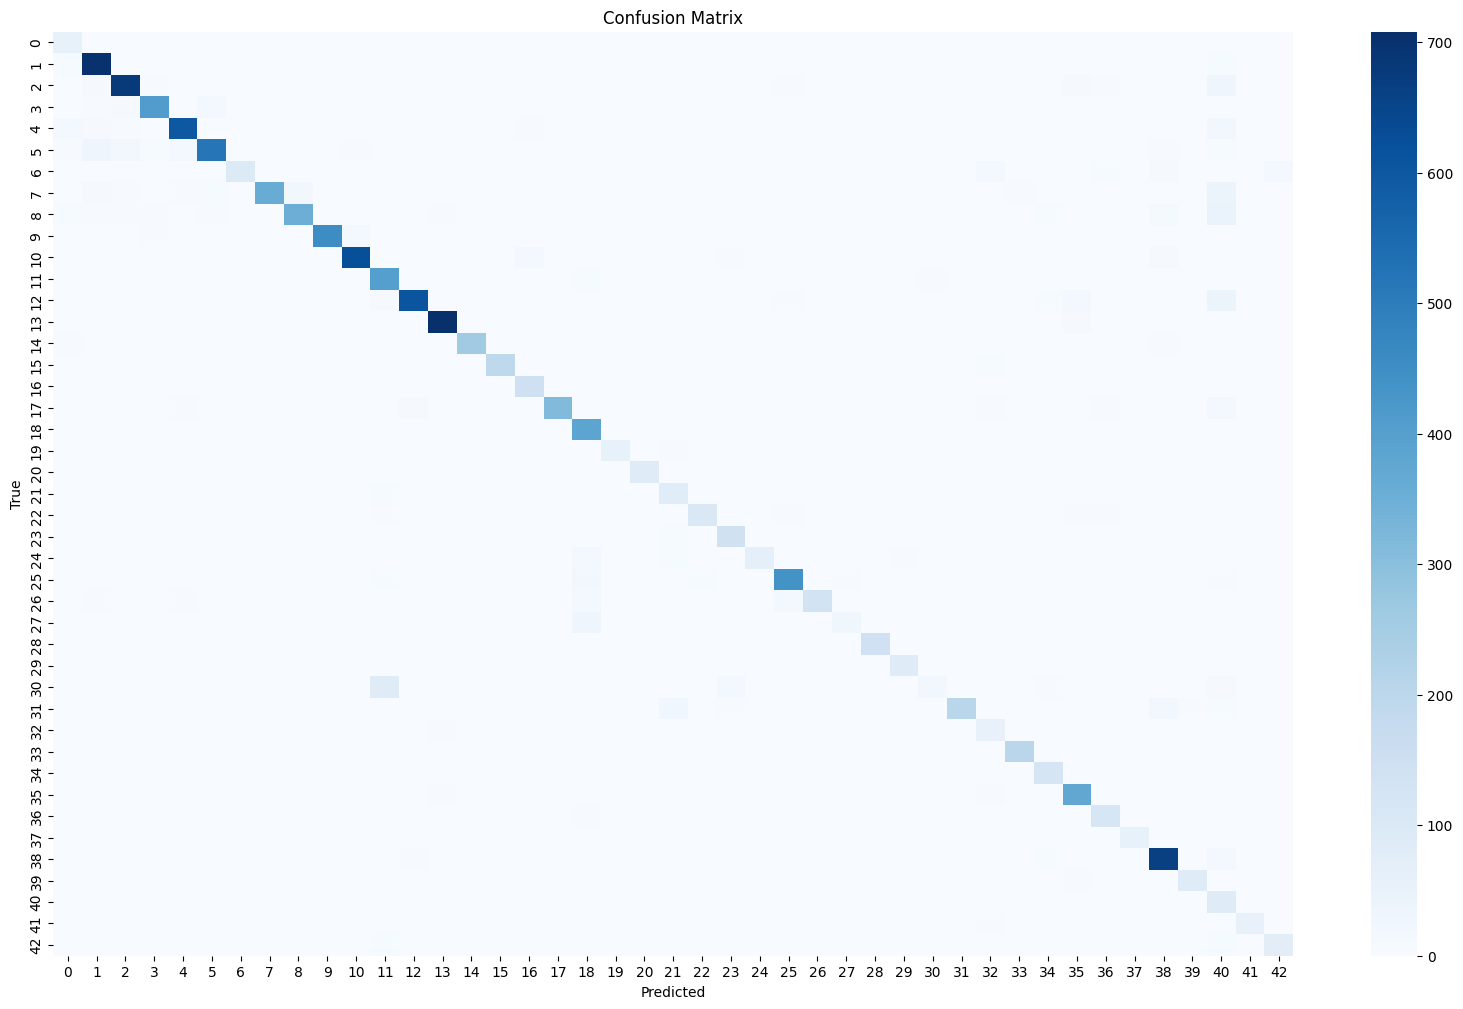

In [114]:
# ✅ Load test data using CSV
print("\n📄 Loading test data from CSV...")
df_test = pd.read_csv(test_csv_path)

# Extract file paths and class IDs
test_labels = df_test["ClassId"].values     # ✅ column G
test_filenames = df_test["Path"].values     # ✅ column H


X_test, y_test = [], []

for file_path, label in tqdm.tqdm(zip(test_filenames, test_labels), total=len(test_filenames)):
    full_path = os.path.join(data_path, str(file_path))

    try:
        img = Image.open(full_path).resize((32, 32))
        X_test.append(np.array(img))
        y_test.append(int(label))
    except Exception as e:
        print(f"⚠️ Skipping {file_path}: {e}")

X_test = np.array(X_test) / 255.0
y_test = np.array(y_test)

print(f"✅ Loaded {len(X_test)} test images with labels")

# ✅ Run predictions
predictions = np.argmax(model.predict(X_test), axis=1)

# ✅ Compute metrics
print(f"\n✅ Test Accuracy: {accuracy_score(y_test, predictions)*100:.2f}%")

# ✅ Confusion Matrix
cfm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(20, 12))
sns.heatmap(cfm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [115]:
accuracy_score(y_test, predictions)

0.9007917656373713

<Axes: >

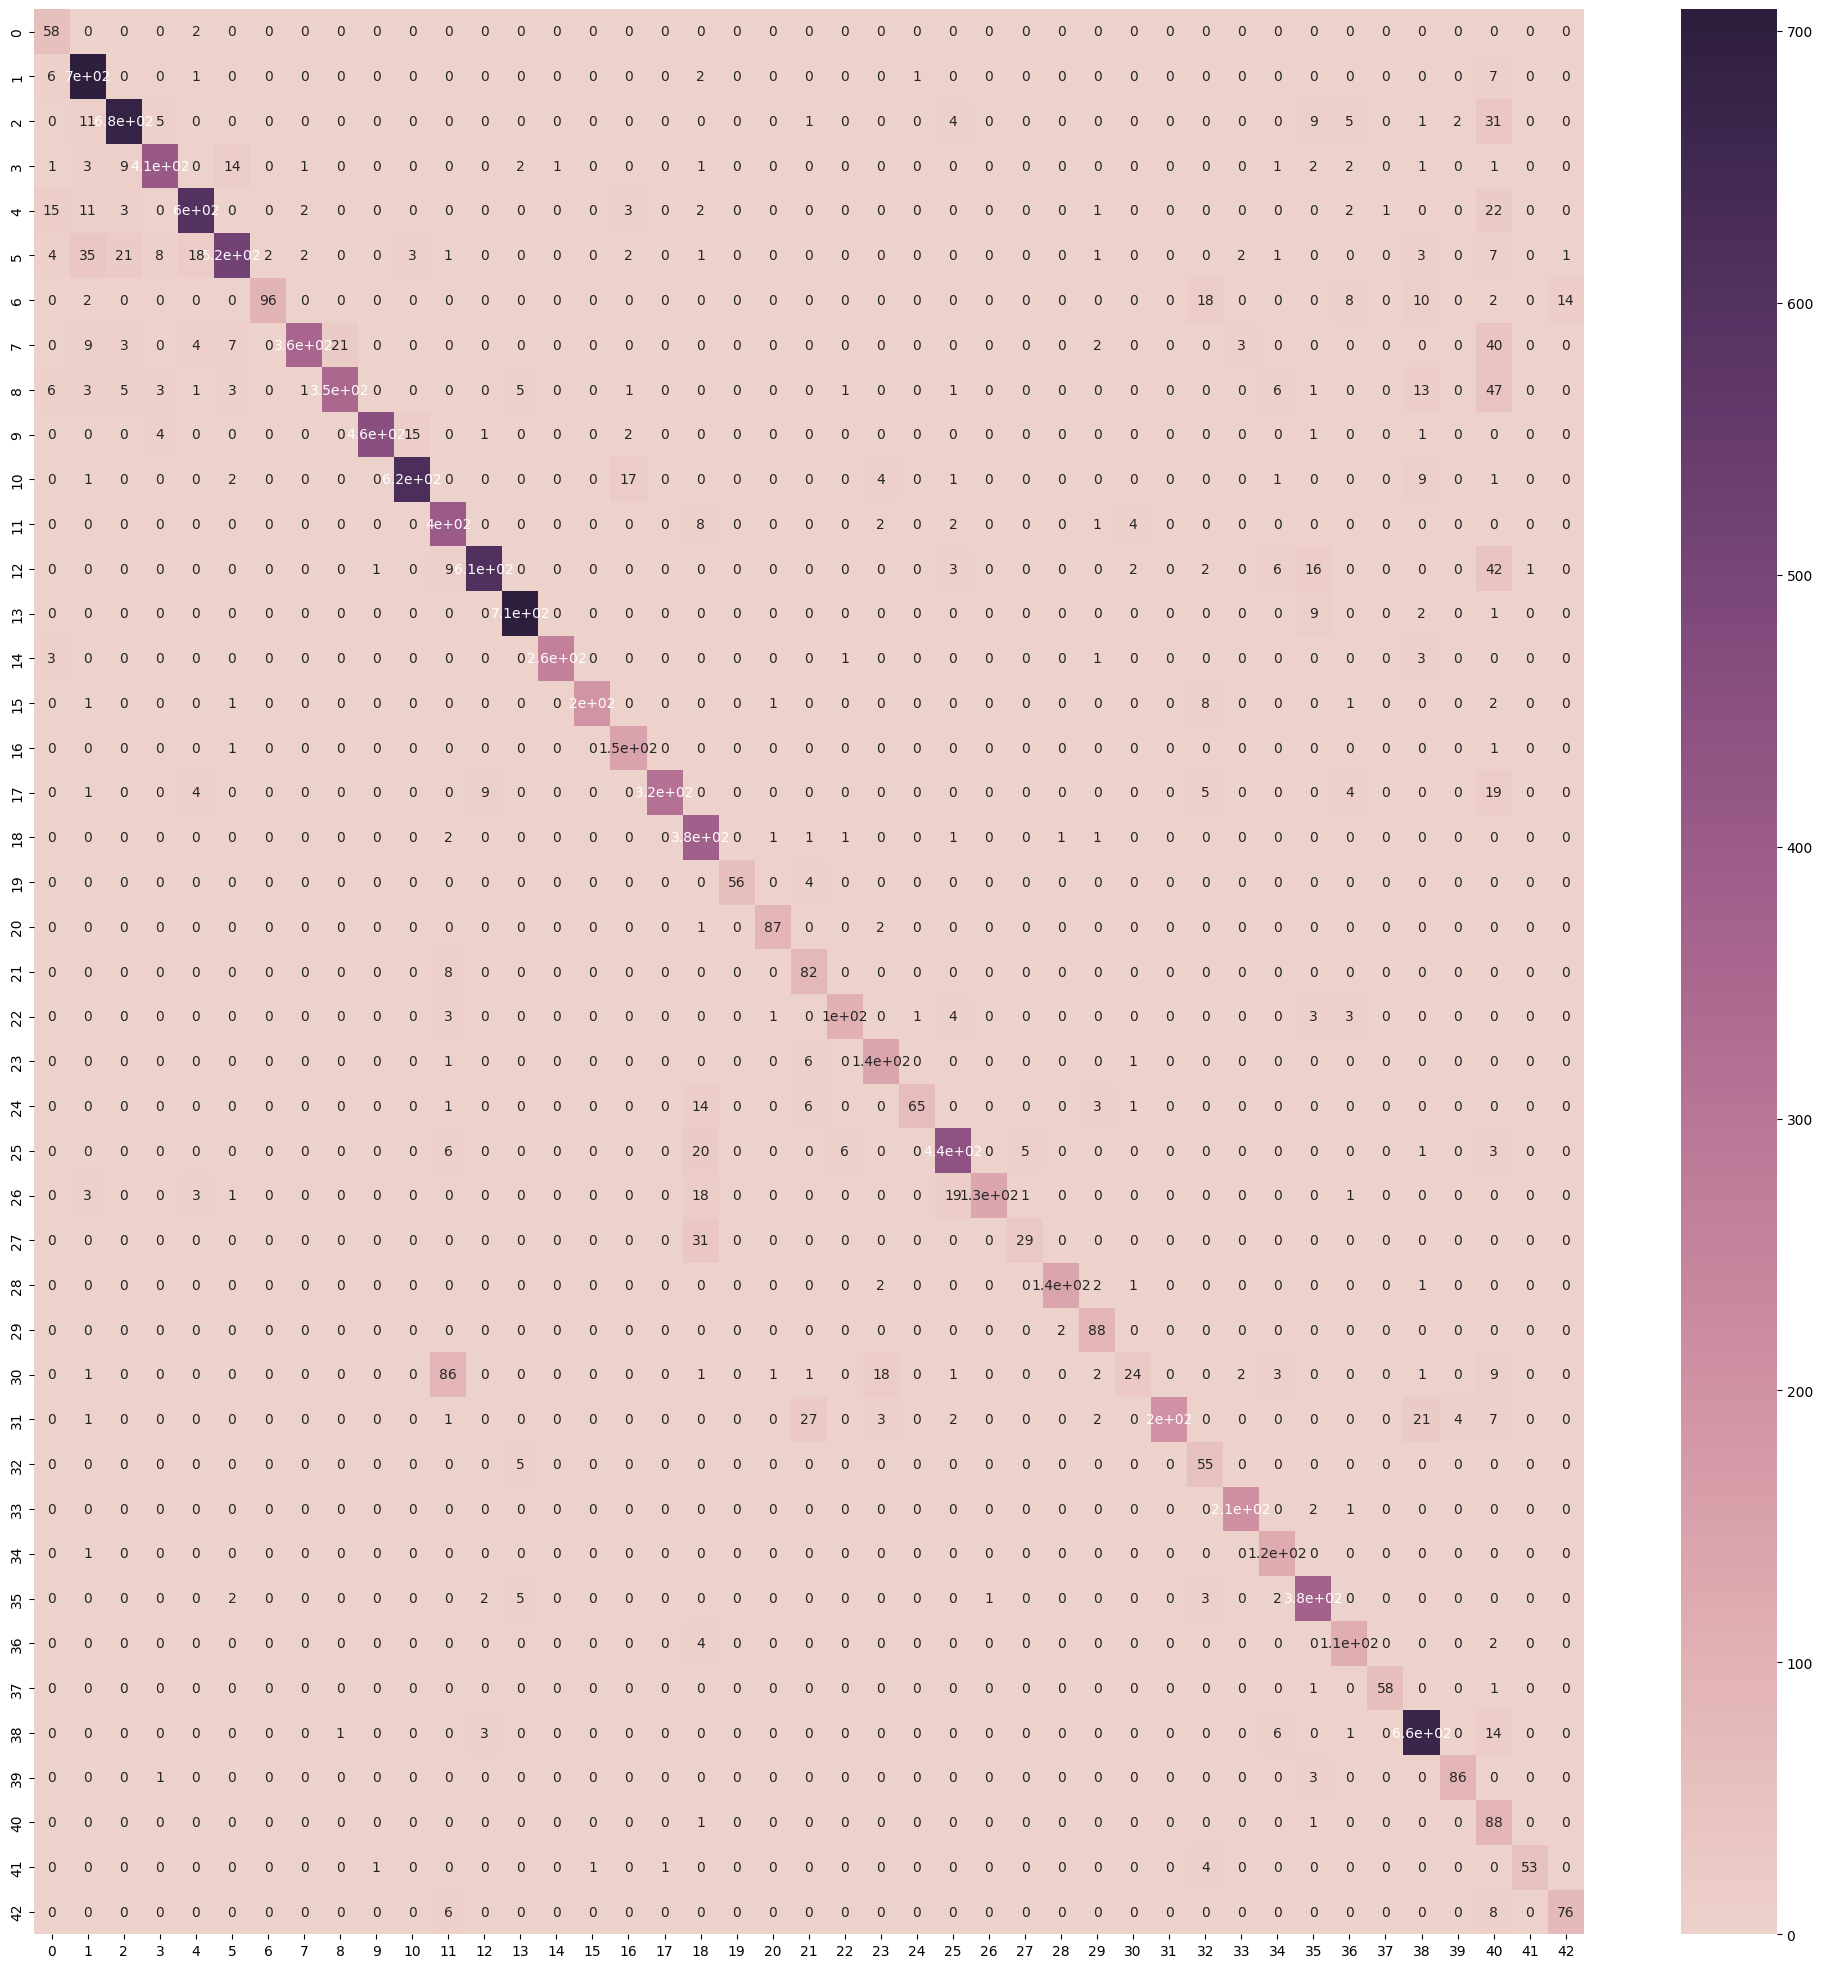

In [116]:
df_cfm = pd.DataFrame(cfm, index = [i for i in range(num_classes)], columns = [i for i in range(num_classes)])
plt.figure(figsize = (25, 25))
sns.heatmap(df_cfm, annot=True, cmap=sns.cubehelix_palette(as_cmap=True))

### Visualize Results

In [120]:
inv_class_dict = {v: k for k, v in class_dict.items()}


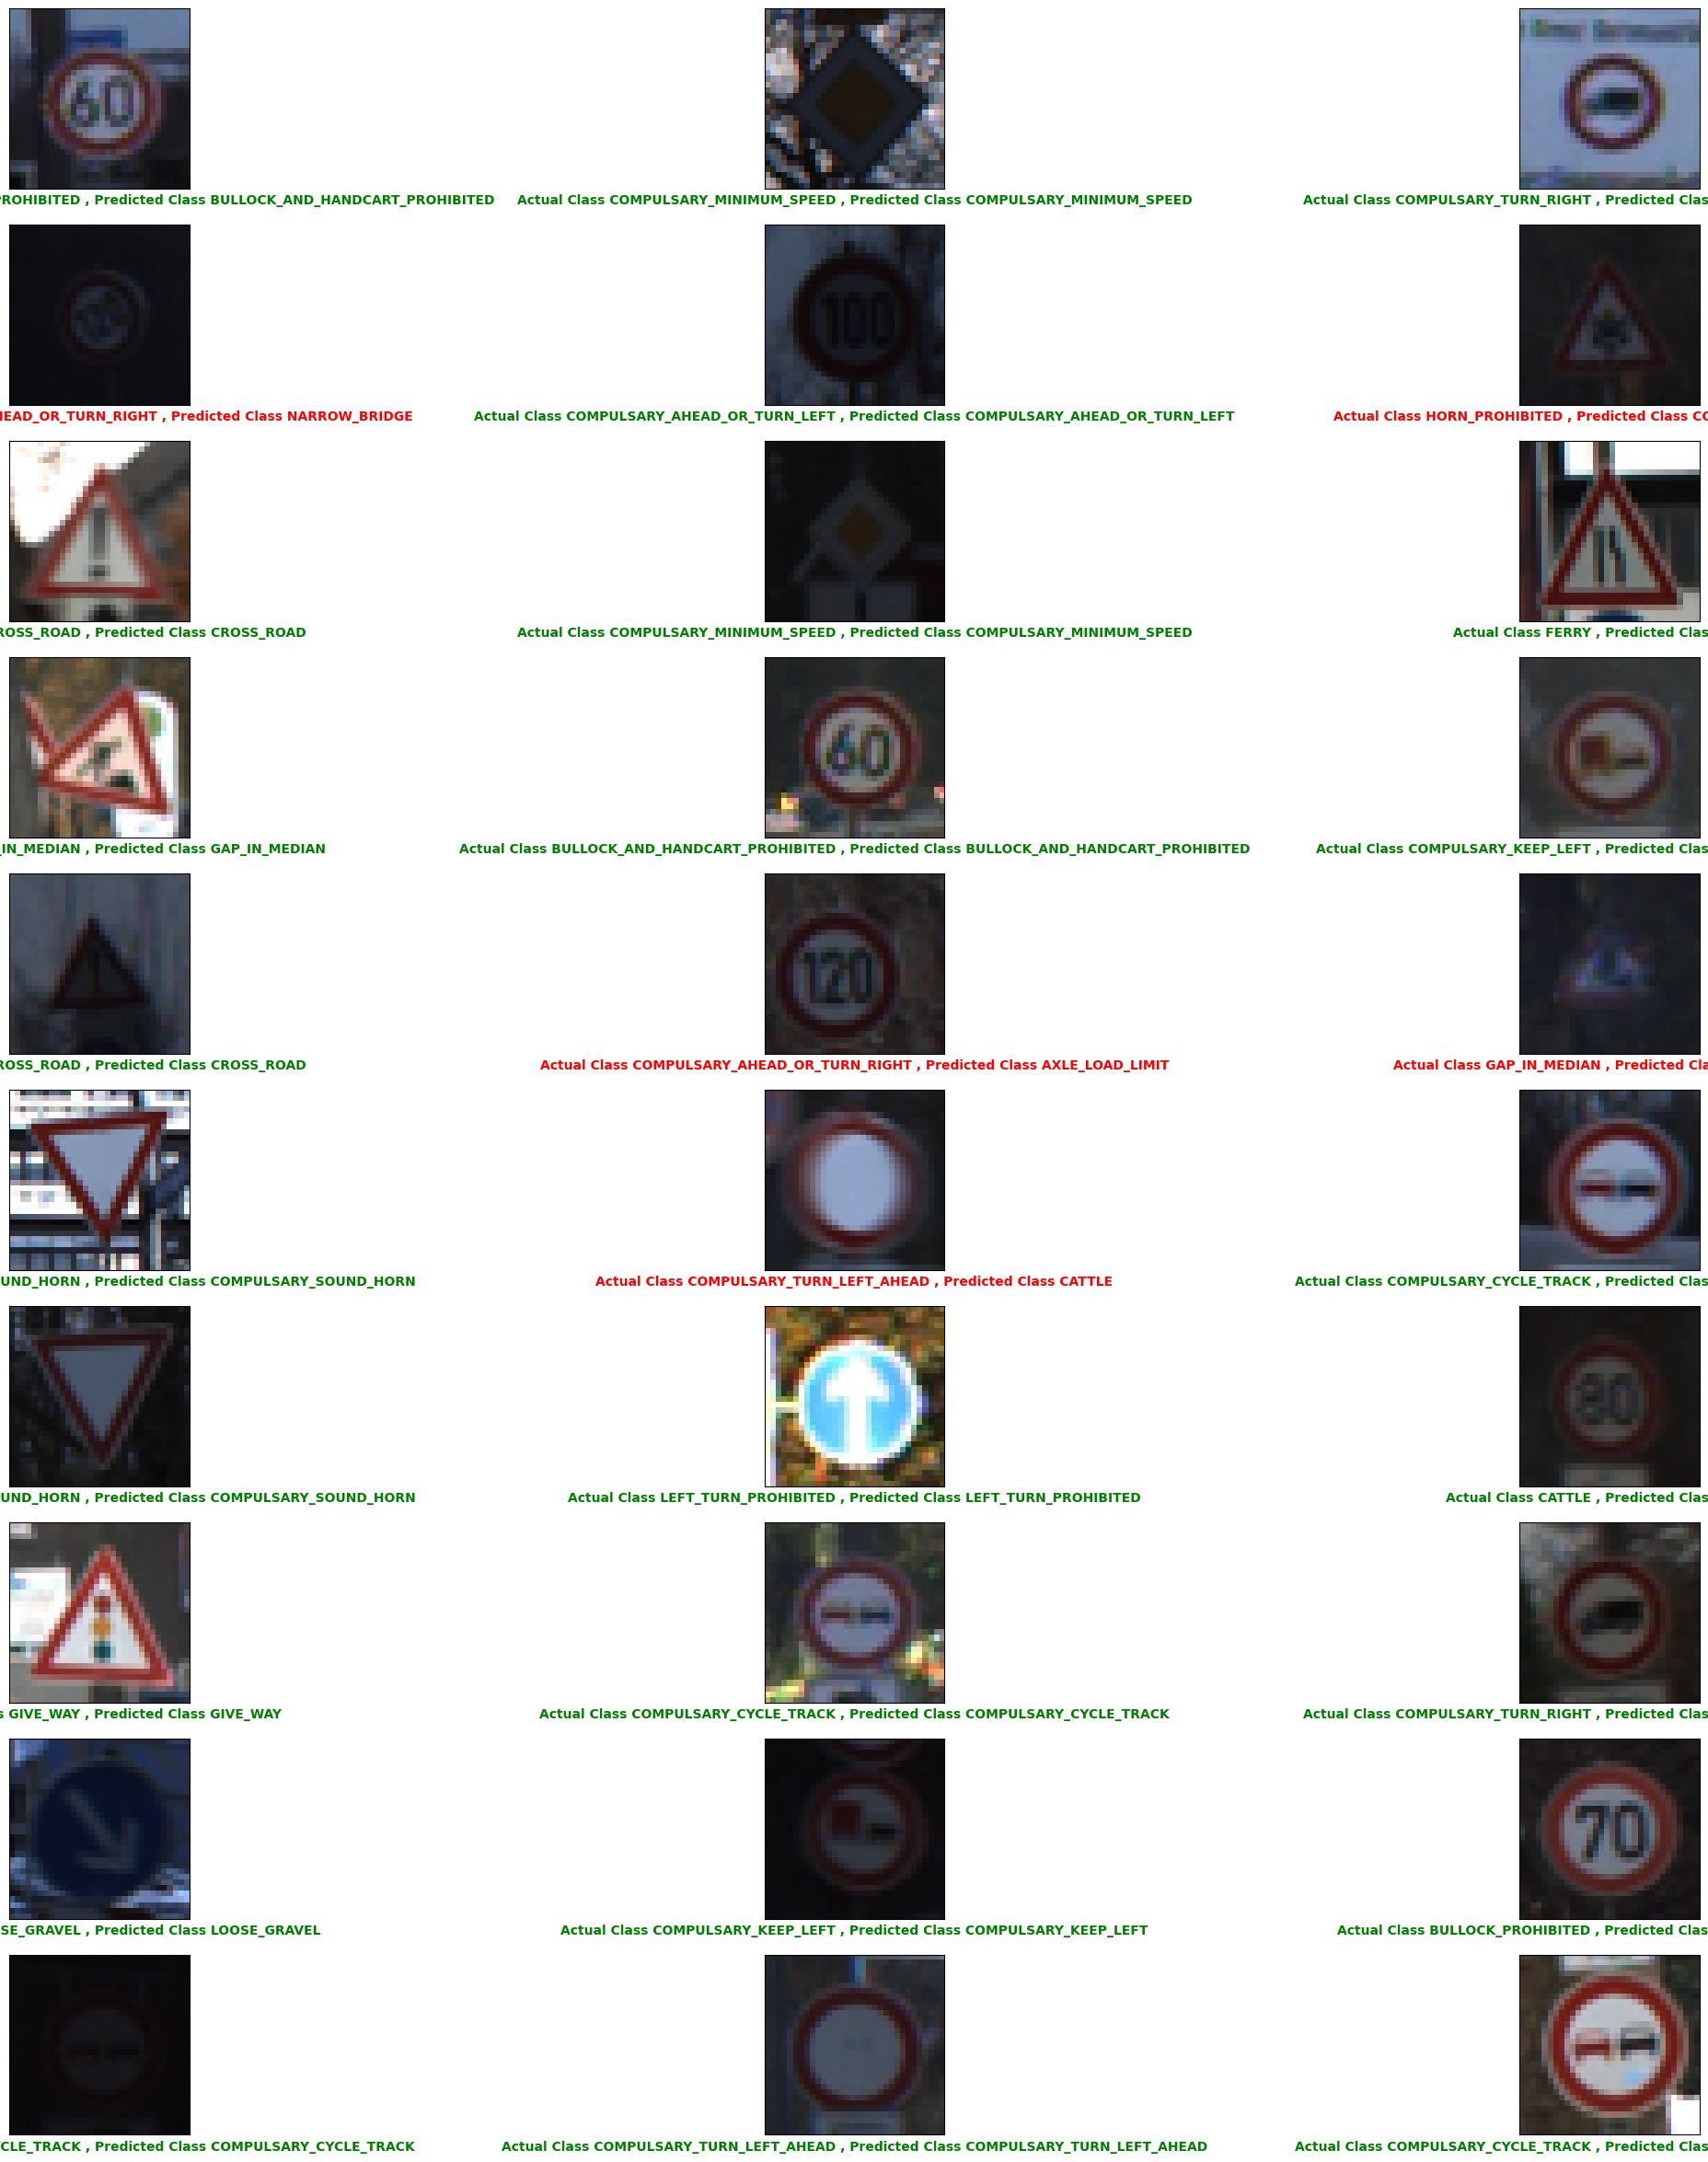

In [121]:
plt.figure(figsize = (30, 30))
start_index = 36
for i in range(30):
    plt.subplot(10, 3, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    prediction = predictions[start_index + i]
    ground_truth = y_test[start_index + i]
    col = 'g'
    if prediction != ground_truth:
        col = 'r'
    plt.xlabel('Actual Class {} , Predicted Class {}'.format(inv_class_dict[ground_truth], inv_class_dict[prediction]), color = col, weight = 'bold')
    plt.imshow(X_test[start_index + i])
plt.show()

In [ ]:
# Save the model for further implementation
os.mkdir('models')
model.save('models/traffic_sign_detection_gtsrb.h5')

## Future Work
1. Use this model and custom dataset to run inference on video using an object detection framework
2. Implement OCR capability for non English speaking countries
3. Create an interactive dashboard with labelling
4. Deploy this model on Streamlit 